# Permutations

In the previous notebook we learned the **product rule** and **sum rule** of counting, and saw how naive counting can lead to **double counting**. In this notebook we tackle a specific and very common counting question:

> **In how many ways can we arrange (order) objects?**

We will:
1. Derive the permutation formula from the product rule
2. Handle the case where **all objects are distinct**
3. Handle the case where **some objects are repeated** (not all distinct)
4. Work through examples and practice problems

In [103]:
import math
from itertools import permutations
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from collections import Counter

print("Libraries imported successfully!")

Libraries imported successfully!


---
## 1. Motivating the Problem

Suppose we have 3 books — **A**, **B**, **C** — and we want to arrange them on a shelf.

Using the **product rule**:
- Position 1: **3** choices (any of the 3 books)
- Position 2: **2** choices (whichever 2 remain)
- Position 3: **1** choice (the last book)

$$\text{Total arrangements} = 3 \times 2 \times 1 = 6$$

Let's verify by listing them all:

In [104]:
books = ["A", "B", "C"]

all_arrangements = list(permutations(books))

print(f"Books: {books}")
print(f"Total arrangements: {len(all_arrangements)}")
print()
for i, arr in enumerate(all_arrangements, 1):
    print(f"  {i}. {' → '.join(arr)}")

Books: ['A', 'B', 'C']
Total arrangements: 6

  1. A → B → C
  2. A → C → B
  3. B → A → C
  4. B → C → A
  5. C → A → B
  6. C → B → A


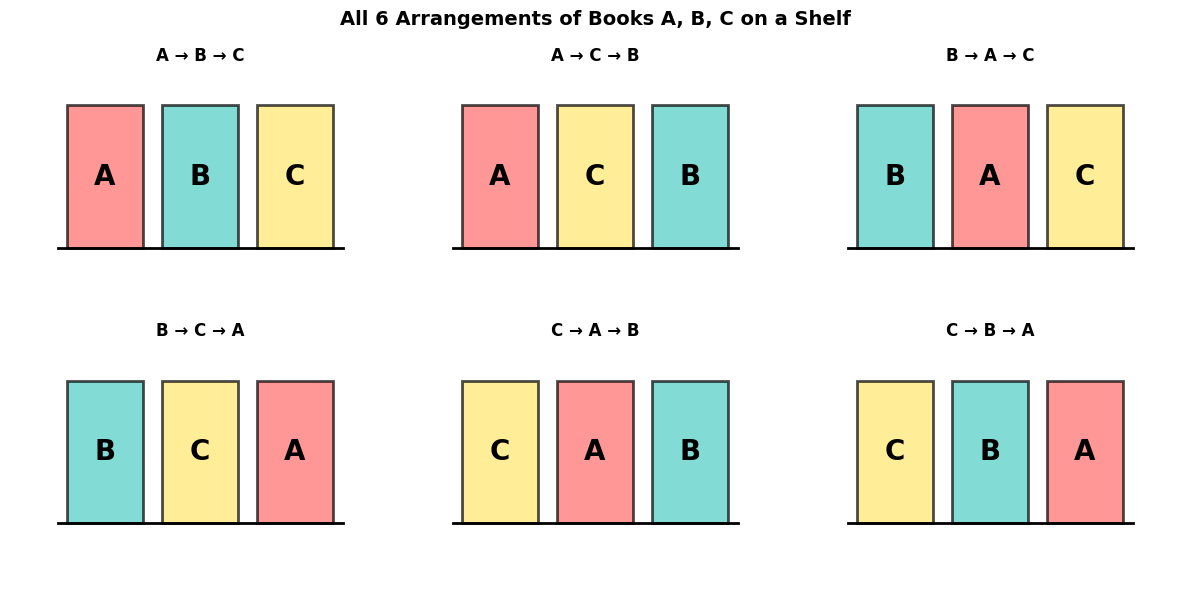

✓ Visual: All possible book arrangements


In [105]:
# Visualize the 6 arrangements of books A, B, C
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
fig.suptitle('All 6 Arrangements of Books A, B, C on a Shelf', fontsize=14, fontweight='bold')

colors = {'A': '#FF6B6B', 'B': '#4ECDC4', 'C': '#FFE66D'}

for idx, arr in enumerate(all_arrangements):
    ax = axes[idx // 3, idx % 3]
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(0, 2)
    ax.set_title(f"{ ' → '.join(arr)}", fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # Draw shelf
    ax.plot([0, 3], [0.5, 0.5], 'k-', linewidth=2)
    
    # Draw books
    for i, book in enumerate(arr):
        rect = patches.Rectangle((i + 0.1, 0.5), 0.8, 1.2, 
                                linewidth=2, edgecolor='black', 
                                facecolor=colors[book], alpha=0.7)
        ax.add_patch(rect)
        ax.text(i + 0.5, 1.1, book, fontsize=20, fontweight='bold', 
               ha='center', va='center')

plt.tight_layout()
plt.show()

print("✓ Visual: All possible book arrangements")

---
## 2. Deriving the Permutation Formula (All Distinct)

### Arranging all $n$ distinct objects

Generalizing the book example, if we have $n$ **distinct** objects and want to arrange **all** of them:

| Position | Choices available |
|----------|------------------|
| 1st | $n$ |
| 2nd | $n - 1$ |
| 3rd | $n - 2$ |
| ... | ... |
| $n$-th | $1$ |

By the **product rule** (each position is a sequential step):

$$n \times (n-1) \times (n-2) \times \cdots \times 2 \times 1 = n!$$

This product is called **$n$ factorial**, written $n!$

### Definition

$$n! = \prod_{i=1}^{n} i = 1 \times 2 \times 3 \times \cdots \times n$$

By convention: $0! = 1$

In [106]:
# Computing factorials
for n in range(8):
    # Build the multiplication string: 1 × 2 × ... × n
    if n == 0:
        expr = "1 (by convention)"
    else:
        parts = []
        for i in range(1, n + 1):
            parts.append(str(i))
        expr = " × ".join(parts)
    print(f"{n}! = {expr} = {math.factorial(n)}")

0! = 1 (by convention) = 1
1! = 1 = 1
2! = 1 × 2 = 2
3! = 1 × 2 × 3 = 6
4! = 1 × 2 × 3 × 4 = 24
5! = 1 × 2 × 3 × 4 × 5 = 120
6! = 1 × 2 × 3 × 4 × 5 × 6 = 720
7! = 1 × 2 × 3 × 4 × 5 × 6 × 7 = 5040


Notice how quickly factorials grow — this is why brute-force enumeration becomes impractical even for moderate $n$.

In [107]:
# Factorial growth
for n in [10, 15, 20, 25, 52]:
    print(f"{n:>2}! = {math.factorial(n):,}")

print()
print("52! is the number of ways to shuffle a standard deck of cards.")
print(f"It has {len(str(math.factorial(52)))} digits!")

10! = 3,628,800
15! = 1,307,674,368,000
20! = 2,432,902,008,176,640,000
25! = 15,511,210,043,330,985,984,000,000
52! = 80,658,175,170,943,878,571,660,636,856,403,766,975,289,505,440,883,277,824,000,000,000,000

52! is the number of ways to shuffle a standard deck of cards.
It has 68 digits!


---
## 3. Choosing and Arranging $r$ out of $n$ — $P(n, r)$

Often we don't arrange **all** $n$ objects — we pick **$r$** of them and arrange those.

### Derivation using the Product Rule

Pick $r$ objects from $n$ distinct objects, **order matters**:

| Position | Choices |
|----------|--------|
| 1st | $n$ |
| 2nd | $n - 1$ |
| 3rd | $n - 2$ |
| ... | ... |
| $r$-th | $n - r + 1$ |

By the product rule:

$$P(n, r) = n \times (n-1) \times (n-2) \times \cdots \times (n - r + 1)$$

This is a product of $r$ consecutive descending integers starting from $n$.

### Compact formula using factorials

$$P(n, r) = \frac{n!}{(n - r)!}$$

**Why?** Because $n! = n \times (n-1) \times \cdots \times (n-r+1) \times (n-r)!$, so dividing by $(n-r)!$ cancels the unwanted tail:

$$\frac{n!}{(n-r)!} = \frac{\cancel{1 \times 2 \times \cdots \times (n-r)} \times (n-r+1) \times \cdots \times n}{\cancel{1 \times 2 \times \cdots \times (n-r)}}$$

### Special cases
- $P(n, n) = \frac{n!}{0!} = n!$ — arranging all $n$ objects
- $P(n, 1) = n$ — just picking one object
- $P(n, 0) = 1$ — doing nothing (one way to do nothing)

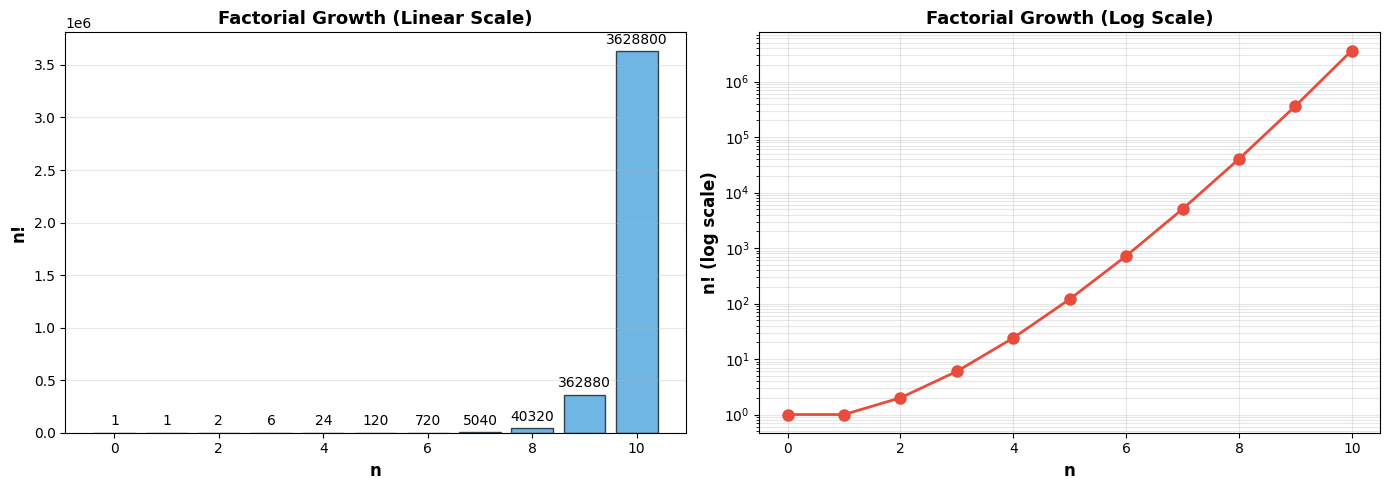

✓ Visual: How fast factorials grow


In [108]:
# Visualize factorial growth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
n_vals = list(range(11))
fact_vals = [math.factorial(n) for n in n_vals]

ax1.bar(n_vals, fact_vals, color='#3498db', alpha=0.7, edgecolor='black')
ax1.set_xlabel('n', fontsize=12, fontweight='bold')
ax1.set_ylabel('n!', fontsize=12, fontweight='bold')
ax1.set_title('Factorial Growth (Linear Scale)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(fact_vals):
    ax1.text(i, v + max(fact_vals)*0.02, f'{v}', ha='center', fontsize=10)

# Log scale - to see pattern better
ax2.semilogy(n_vals, fact_vals, 'o-', color='#e74c3c', linewidth=2, markersize=8)
ax2.set_xlabel('n', fontsize=12, fontweight='bold')
ax2.set_ylabel('n! (log scale)', fontsize=12, fontweight='bold')
ax2.set_title('Factorial Growth (Log Scale)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("✓ Visual: How fast factorials grow")

In [109]:
def P(n, r):
    """Compute P(n, r) = n! / (n - r)!"""
    return math.factorial(n) // math.factorial(n - r)

# Verify: P(n, r) = product of r terms
def P_product(n, r):
    """Compute P(n, r) using the product rule directly."""
    result = 1
    for i in range(r):
        result *= (n - i)
    return result

# Show both methods agree
print("n    r    P(n,r) [factorial]    P(n,r) [product]    Match?")
print("-" * 62)
for n, r in [(5, 3), (6, 2), (8, 4), (10, 5), (4, 4), (7, 1), (5, 0)]:
    p_fact = P(n, r)
    p_prod = P_product(n, r)
    match = "✓" if p_fact == p_prod else "✗"
    print(f"{n:<5}{r:<5}{p_fact:<22}{p_prod:<22}{match}")

n    r    P(n,r) [factorial]    P(n,r) [product]    Match?
--------------------------------------------------------------
5    3    60                    60                    ✓
6    2    30                    30                    ✓
8    4    1680                  1680                  ✓
10   5    30240                 30240                 ✓
4    4    24                    24                    ✓
7    1    7                     7                     ✓
5    0    1                     1                     ✓


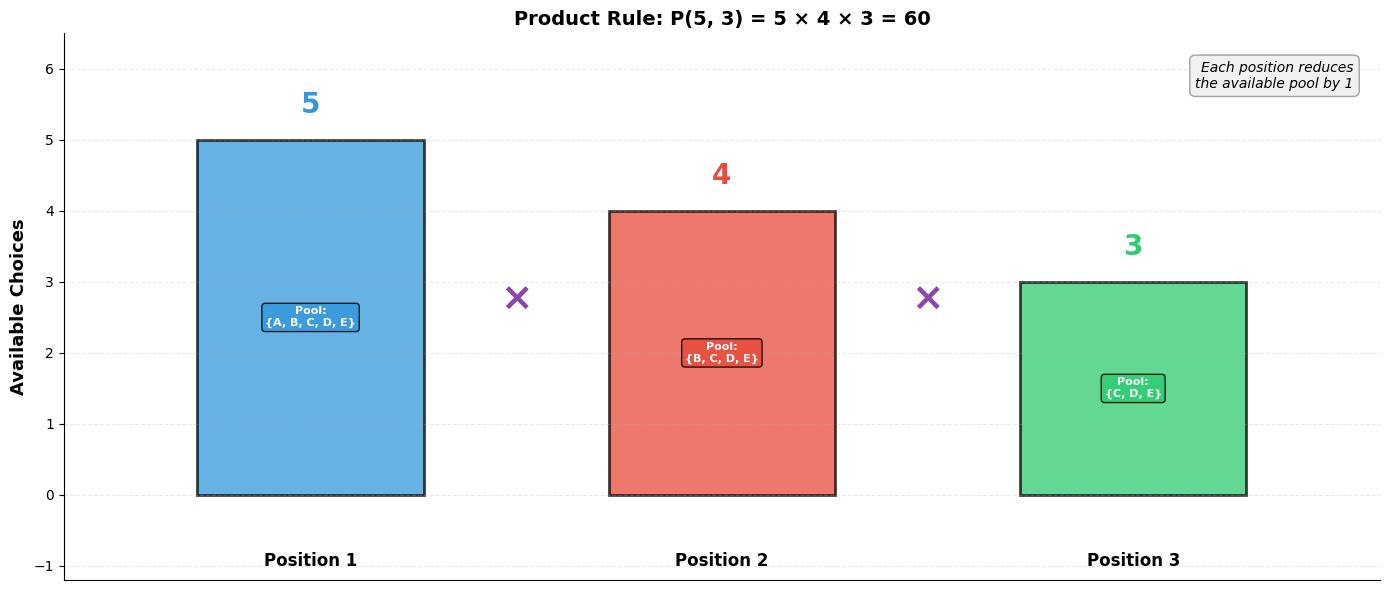

✓ Visual: Product Rule — P(5, 3) = 60


In [110]:
# Visualize P(n,r) using a diminishing-pool concept
fig, ax = plt.subplots(figsize=(14, 6))

# Example: P(5, 3) — choosing and arranging 3 from 5
n, r = 5, 3
objects = ['A', 'B', 'C', 'D', 'E']
choices_at_pos = [n - i for i in range(r)]

# Draw bars for choices at each position
colors_choices = ['#3498db', '#e74c3c', '#2ecc71']
x_positions = np.arange(r)
bars = ax.bar(x_positions, choices_at_pos, color=colors_choices, alpha=0.75,
              edgecolor='black', linewidth=2, width=0.55)

# Label each bar with the count and available objects
remaining = list(objects)
for i, (pos_x, choices) in enumerate(zip(x_positions, choices_at_pos)):
    # Big number above bar
    ax.text(pos_x, choices + 0.3, str(choices), ha='center', va='bottom',
            fontsize=20, fontweight='bold', color=colors_choices[i])
    # Position label below bar
    ax.text(pos_x, -0.8, f'Position {i+1}', ha='center', va='top',
            fontsize=12, fontweight='bold')
    # Available objects inside bar
    pool_str = ', '.join(remaining)
    ax.text(pos_x, choices / 2, f'Pool:\n{{{pool_str}}}', ha='center', va='center',
            fontsize=8, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=colors_choices[i], alpha=0.85))
    remaining.pop(0)  # simulate one chosen each step

# Multiplication connectors
for i in range(r - 1):
    ax.text(i + 0.5, max(choices_at_pos) * 0.55, '×', ha='center', va='center',
            fontsize=28, fontweight='bold', color='#8e44ad')

ax.set_ylim(-1.2, max(choices_at_pos) + 1.5)
ax.set_xlim(-0.6, r - 0.4)
ax.set_ylabel('Available Choices', fontsize=13, fontweight='bold')
product = math.prod(choices_at_pos)
ax.set_title(f'Product Rule: P({n}, {r}) = {" × ".join(map(str, choices_at_pos))} = {product}',
             fontsize=14, fontweight='bold')
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle='--')

# Insight annotation
ax.text(0.98, 0.95, 'Each position reduces\nthe available pool by 1',
        transform=ax.transAxes, fontsize=10, ha='right', va='top', style='italic',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f0f0', edgecolor='#999', alpha=0.9))

plt.tight_layout()
plt.show()

print(f"✓ Visual: Product Rule — P({n}, {r}) = {product}")

### Example 1: Race Podium

In a race with **10 runners**, how many ways can the **gold, silver, and bronze** medals be awarded?

We are choosing 3 from 10, and **order matters** (gold ≠ silver ≠ bronze).

$$P(10, 3) = 10 \times 9 \times 8 = 720$$

In [111]:
n, r = 10, 3
result = P(n, r)

print(f"Runners: {n}")
print(f"Medal positions: {r} (gold, silver, bronze)")
print(f"P({n}, {r}) = {n} × {n-1} × {n-2} = {result}")

Runners: 10
Medal positions: 3 (gold, silver, bronze)
P(10, 3) = 10 × 9 × 8 = 720


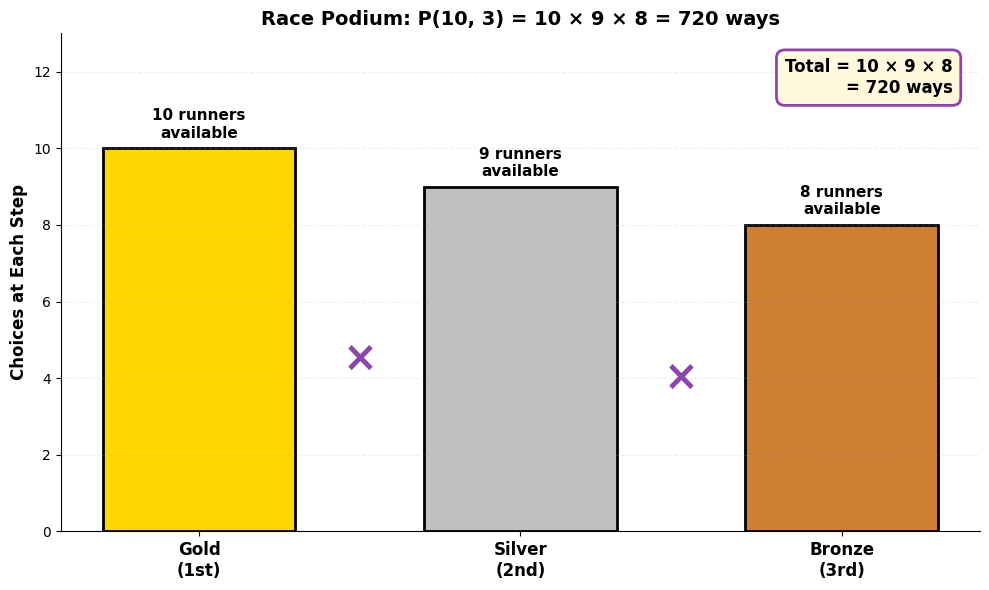

In [112]:
# Visualize the podium for race example
fig, ax = plt.subplots(figsize=(10, 6))

# Draw a proper podium: heights represent rank (taller = better), bar values show choices
podium_labels = ['Gold\n(1st)', 'Silver\n(2nd)', 'Bronze\n(3rd)']
podium_heights = [3, 2, 1]  # podium visual heights
choices = [10, 9, 8]
colors_medal = ['#FFD700', '#C0C0C0', '#CD7F32']

x_pos = [0, 1, 2]
bars = ax.bar(x_pos, choices, color=colors_medal, edgecolor='black', linewidth=2, width=0.6)

# Add the number of available runners on each bar
for i, (choice, bar) in enumerate(zip(choices, bars)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2, 
            f'{choice} runners\navailable', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Highlight the product rule with styled connectors
for i in range(2):
    mid_x = (x_pos[i] + x_pos[i+1]) / 2
    mid_y = min(choices[i], choices[i+1]) / 2
    ax.text(mid_x, mid_y, '×', ha='center', va='center', fontsize=30, fontweight='bold', 
            color='#8e44ad', zorder=5)

ax.set_ylim(0, 13)
ax.set_ylabel('Choices at Each Step', fontsize=12, fontweight='bold')
ax.set_title('Race Podium: P(10, 3) = 10 × 9 × 8 = 720 ways', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(podium_labels, fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add result annotation
ax.text(0.97, 0.95, 'Total = 10 × 9 × 8\n= 720 ways', transform=ax.transAxes,
        fontsize=12, fontweight='bold', ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8DC', edgecolor='#8e44ad', linewidth=2))

plt.tight_layout()
plt.show()

### Example 2: Seating Arrangement

There are **7 people** and **4 chairs** in a row. How many seating arrangements are possible?

$$P(7, 4) = 7 \times 6 \times 5 \times 4 = 840$$

In [113]:
n, r = 7, 4
result = P(n, r)

parts = []
for i in range(r):
    parts.append(str(n - i))
terms = " × ".join(parts)

print(f"People: {n}, Chairs: {r}")
print(f"P({n}, {r}) = {terms} = {result}")
print()
print(f"Using factorial formula: {n}! / ({n}-{r})! = {math.factorial(n)} / {math.factorial(n-r)} = {result}")

People: 7, Chairs: 4
P(7, 4) = 7 × 6 × 5 × 4 = 840

Using factorial formula: 7! / (7-4)! = 5040 / 6 = 840


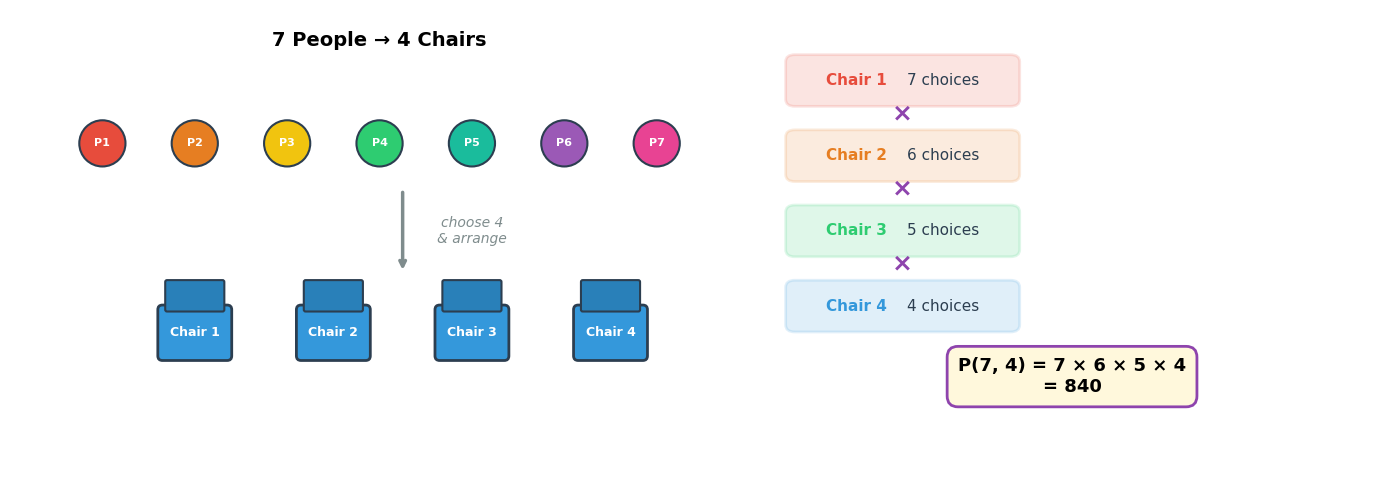

✓ Visual: Seating arrangement — P(7,4) = 840


In [114]:
# Visualize seating arrangement
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.2, 1]})

# Left: Show the problem setup
ax = axes[0]
n_people, n_chairs = 7, 4
seating_result = P(7, 4)  # compute directly: 840

ax.set_xlim(-0.5, 7.5)
ax.set_ylim(-0.5, 3.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'{n_people} People → {n_chairs} Chairs', fontsize=14, fontweight='bold', pad=10)

# Draw chairs in a row at the bottom
chair_positions = np.linspace(1.5, 6, n_chairs)
for i, cx in enumerate(chair_positions):
    # Chair seat
    rect = patches.FancyBboxPatch((cx - 0.35, 0.3), 0.7, 0.5,
                                   boxstyle="round,pad=0.05",
                                   facecolor='#3498db', edgecolor='#2c3e50', linewidth=2)
    ax.add_patch(rect)
    # Chair back
    rect_back = patches.FancyBboxPatch((cx - 0.3, 0.8), 0.6, 0.3,
                                        boxstyle="round,pad=0.02",
                                        facecolor='#2980b9', edgecolor='#2c3e50', linewidth=1.5)
    ax.add_patch(rect_back)
    ax.text(cx, 0.55, f'Chair {i+1}', ha='center', va='center', fontsize=9, fontweight='bold', color='white')

# Draw people in a line above
people_x = np.linspace(0.5, 6.5, n_people)
people_y = 2.6
person_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#1abc9c', '#9b59b6', '#e84393']
for i, px in enumerate(people_x):
    # Head
    circle = patches.Circle((px, people_y), 0.25, facecolor=person_colors[i],
                             edgecolor='#2c3e50', linewidth=1.5, zorder=3)
    ax.add_patch(circle)
    ax.text(px, people_y, f'P{i+1}', ha='center', va='center',
            fontsize=8, fontweight='bold', color='white', zorder=4)

# Arrow from people row to chairs
ax.annotate('', xy=(3.75, 1.2), xytext=(3.75, 2.1),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#7f8c8d'))
ax.text(4.5, 1.65, 'choose 4\n& arrange', ha='center', va='center', fontsize=10,
        style='italic', color='#7f8c8d')

# Right: Show the step-by-step calculation
ax = axes[1]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# Step-by-step boxes
steps = [
    ('Chair 1', '7 choices', '#e74c3c'),
    ('Chair 2', '6 choices', '#e67e22'),
    ('Chair 3', '5 choices', '#2ecc71'),
    ('Chair 4', '4 choices', '#3498db'),
]
for i, (label, desc, color) in enumerate(steps):
    y = 8.5 - i * 1.6
    rect = patches.FancyBboxPatch((0.5, y - 0.4), 3.5, 0.8,
                                   boxstyle="round,pad=0.15",
                                   facecolor=color, alpha=0.15,
                                   edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(1, y, label, fontsize=11, fontweight='bold', va='center', color=color)
    ax.text(3.5, y, desc, fontsize=11, va='center', ha='right', color='#2c3e50')
    if i < 3:
        ax.text(2.25, y - 0.7, '×', fontsize=18, ha='center', va='center',
                fontweight='bold', color='#8e44ad')

# Result box
ax.text(5, 2.2, f'P(7, 4) = 7 × 6 × 5 × 4\n= {seating_result}', fontsize=13,
        fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#FFF8DC',
                  edgecolor='#8e44ad', linewidth=2))

plt.tight_layout()
plt.show()

print(f"✓ Visual: Seating arrangement — P(7,4) = {seating_result}")

### Example 3: Word Arrangements

How many 3-letter "words" (not necessarily meaningful) can be formed from the letters of **PYTHON** (6 distinct letters), if **no letter is repeated**?

$$P(6, 3) = 6 \times 5 \times 4 = 120$$

In [115]:
word = "PYTHON"
r = 3
n = len(word)

result = P(n, r)
print(f"Letters: {list(word)} ({n} distinct)")
print(f"Choosing {r} letters, order matters, no repetition")
print(f"P({n}, {r}) = {result}")
print()

# Show a few of them
sample = list(permutations(word, r))
print(f"First 10 of {len(sample)} arrangements:")
for i, arr in enumerate(sample[:10], 1):
    print(f"  {i:>2}. {''.join(arr)}")
print(f"  ...")

Letters: ['P', 'Y', 'T', 'H', 'O', 'N'] (6 distinct)
Choosing 3 letters, order matters, no repetition
P(6, 3) = 120

First 10 of 120 arrangements:
   1. PYT
   2. PYH
   3. PYO
   4. PYN
   5. PTY
   6. PTH
   7. PTO
   8. PTN
   9. PHY
  10. PHT
  ...


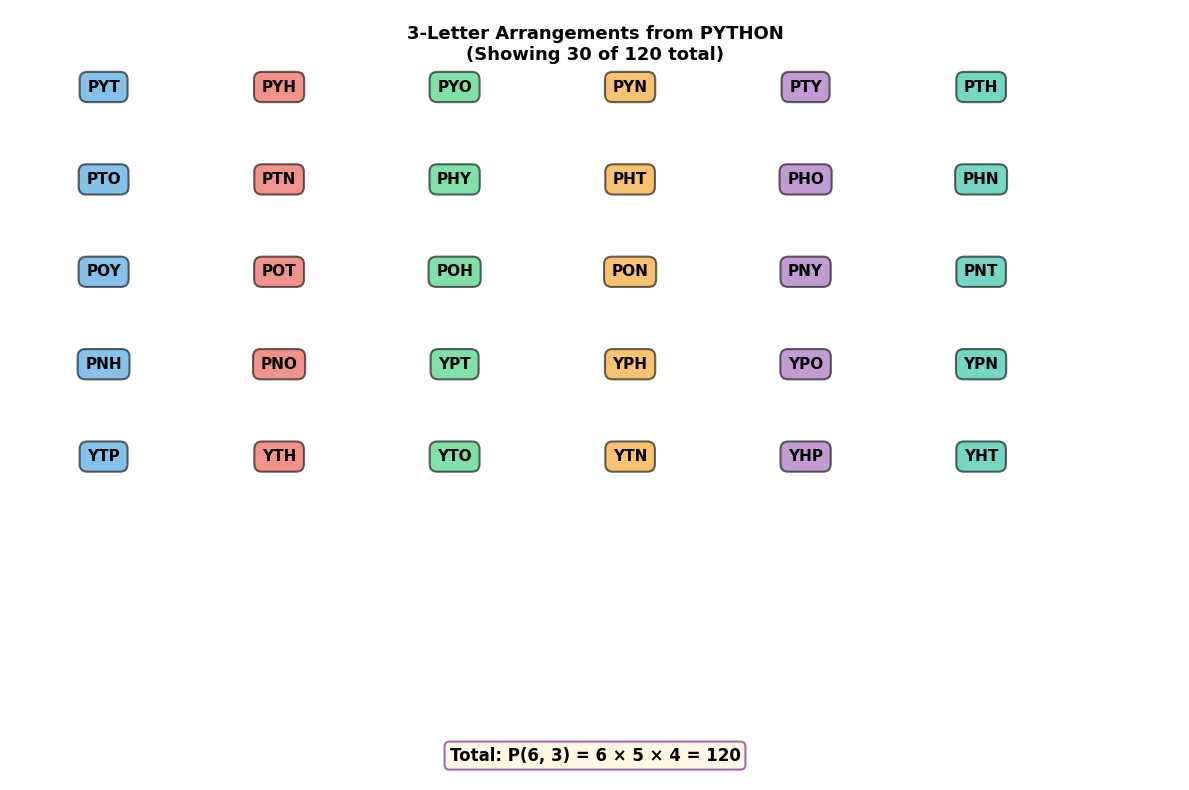

✓ Visual: 3-letter word arrangements from PYTHON — P(6,3) = 120


In [116]:
# Visualize word arrangements as a grid
word = "PYTHON"
r = 3

sample = list(permutations(word, r))
total_perms = P(len(word), r)  # compute directly: 120

# Create a grid showing first 30 arrangements
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

n_show = 30
cols = 6
rows = (n_show + cols - 1) // cols

ax.text(0.5, 0.98, f'3-Letter Arrangements from PYTHON\n(Showing {n_show} of {total_perms} total)',
        ha='center', va='top', fontsize=13, fontweight='bold', transform=ax.transAxes)

palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
for idx in range(n_show):
    row = idx // cols
    col = idx % cols
    x = 0.08 + col * 0.15
    y = 0.90 - row * 0.12
    word_str = ''.join(sample[idx])
    bbox = dict(boxstyle='round,pad=0.5', facecolor=palette[idx % len(palette)],
                alpha=0.6, edgecolor='black', linewidth=1.5)
    ax.text(x, y, word_str, ha='center', va='center', fontsize=11, fontweight='bold',
            transform=ax.transAxes, bbox=bbox)

# Fixed legend — use computed value, not stale `result`
ax.text(0.5, 0.02, f'Total: P(6, 3) = 6 × 5 × 4 = {total_perms}',
        ha='center', va='bottom', fontsize=12, fontweight='bold', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='#FFF8DC', edgecolor='#8e44ad', linewidth=1.5, alpha=0.8))

plt.tight_layout()
plt.show()

print(f"✓ Visual: 3-letter word arrangements from PYTHON — P(6,3) = {total_perms}")

### Example 4: Smudge Attack on a 6-Digit Passcode

You notice **6 smudge marks** on someone's phone screen, each on a **different digit**. The passcode is **6 digits** long.

Since there are 6 smudges and 6 digits in the passcode, **every digit is used exactly once** — all 6 digits are distinct.

An attacker only needs to figure out the **order**. This is a permutation of 6 distinct items:

$$P(6, 6) = 6! = 720$$

That's only 720 attempts — very feasible to brute-force!

**What if only 3 smudges were found?** Then only 3 distinct digits are used across 6 positions, meaning some digits repeat. The exact count depends on how many times each digit repeats — this is where **permutations with repetition** (Section 4) come in.

In [117]:
# 6-digit passcode with 6 distinct smudges
smudges = 6
passcode_length = 6

# All digits are distinct, so we just need the order
possible_passcodes = P(smudges, passcode_length)

print(f"Smudge marks found: {smudges} (all different digits)")
print(f"Passcode length: {passcode_length}")
print(f"Possible passcodes: P({smudges}, {passcode_length}) = {smudges}! = {possible_passcodes}")
print()

# Compare with no information (any digit 0-9 in each position)
no_info = 10 ** passcode_length
print(f"Without smudge info: 10⁶ = {no_info:,}")
print(f"With smudge info:    6!  = {possible_passcodes}")
print(f"Search space reduced by: {no_info // possible_passcodes}x")

Smudge marks found: 6 (all different digits)
Passcode length: 6
Possible passcodes: P(6, 6) = 6! = 720

Without smudge info: 10⁶ = 1,000,000
With smudge info:    6!  = 720
Search space reduced by: 1388x


### Example 5: Smudge Attack — Only 5 Smudges on a 6-Digit Passcode

Now suppose you find only **5 smudge marks**. The passcode is still **6 digits** long.

Since 5 distinct digits fill 6 positions, **exactly one digit is used twice** and the other four are used once. The frequency pattern is always $(2, 1, 1, 1, 1)$.

This is a direct application of the **permutations with repetition** formula:

$$\frac{n!}{n_1! \times n_2! \times n_3! \times n_4! \times n_5!} = \frac{6!}{2! \times 1! \times 1! \times 1! \times 1!} = \frac{720}{2} = 360$$

But **which** of the 5 digits is the repeated one? Each choice gives the same frequency pattern, so by the **sum rule**:

$$\text{Total} = 5 \times \frac{6!}{2! \times 1! \times 1! \times 1! \times 1!} = 5 \times 360 = 1800$$

In [118]:
# 6-digit passcode with 5 distinct smudges
smudges = 5
passcode_length = 6

# Frequency pattern: (2, 1, 1, 1, 1) — one digit repeated, rest appear once
# Permutations with repetition: n! / (n1! × n2! × ... × nk!)
# Only the repeated digit contributes to the denominator (1! = 1 for the rest)
arrangements_per_pattern = math.factorial(passcode_length) // math.factorial(2)

# Which digit is repeated? 5 choices → sum rule
total = smudges * arrangements_per_pattern

print(f"Smudge marks found: {smudges}")
print(f"Passcode length: {passcode_length}")
print(f"Frequency pattern: (2, 1, 1, 1, 1)")
print()
print(f"Permutations with repetition: {passcode_length}! / (2! × 1! × 1! × 1! × 1!) = {math.factorial(passcode_length)} / {math.factorial(2)} = {arrangements_per_pattern}")
print(f"Which digit repeats? {smudges} choices (sum rule)")
print(f"Total: {smudges} × {arrangements_per_pattern} = {total}")
print()

# Compare
no_info = 10 ** passcode_length
six_smudge = math.factorial(6)
print(f"No smudge info: {no_info:,}")
print(f"6 smudges:      {six_smudge}")
print(f"5 smudges:      {total}")
print(f"Search space reduced by: {no_info // total}x (vs no info)")

Smudge marks found: 5
Passcode length: 6
Frequency pattern: (2, 1, 1, 1, 1)

Permutations with repetition: 6! / (2! × 1! × 1! × 1! × 1!) = 720 / 2 = 360
Which digit repeats? 5 choices (sum rule)
Total: 5 × 360 = 1800

No smudge info: 1,000,000
6 smudges:      720
5 smudges:      1800
Search space reduced by: 555x (vs no info)


---
## 4. Permutations with Repeated Elements

### The Problem

What if not all objects are distinct? Consider the word **BANANA**:
- 6 letters total
- But: B appears **1** time, A appears **3** times, N appears **2** times

If all 6 letters were distinct, there would be $6! = 720$ arrangements. But since some letters are **identical**, many of those 720 arrangements look the same.

### Why $n!$ overcounts

Label the A's as $A_1, A_2, A_3$ and N's as $N_1, N_2$. Then:
- $B A_1 N_1 A_2 N_2 A_3$
- $B A_2 N_1 A_1 N_2 A_3$
- $B A_1 N_2 A_2 N_1 A_3$
- ... (and more)

All of these look like **BANANA** when we drop the subscripts. We **overcounted** because swapping identical items among themselves produces the same arrangement.

### Correcting the overcount

- The 3 identical A's can be permuted among themselves in $3!$ ways, all producing the same word.
- The 2 identical N's can be permuted in $2!$ ways.
- The 1 B can be permuted in $1!$ way.

Each **distinct** arrangement was counted $3! \times 2! \times 1! = 12$ times.

### Formula: Permutations with Repetition

If we have $n$ objects where object type $i$ appears $n_i$ times (and $n_1 + n_2 + \cdots + n_k = n$):

$$\text{Distinct permutations} = \frac{n!}{n_1! \times n_2! \times \cdots \times n_k!}$$

This is sometimes called a **multinomial coefficient**.

### Derivation

1. Start: if all $n$ were distinct → $n!$ arrangements (product rule)
2. But swapping identical items of type $i$ among themselves ($n_i!$ ways) gives the same arrangement
3. By the product rule, the total overcount factor is $n_1! \times n_2! \times \cdots \times n_k!$
4. Divide to correct: $\frac{n!}{n_1! \times n_2! \times \cdots \times n_k!}$

### Example 6: Arrangements of BANANA

$$\frac{6!}{3! \times 2! \times 1!} = \frac{720}{6 \times 2 \times 1} = \frac{720}{12} = 60$$

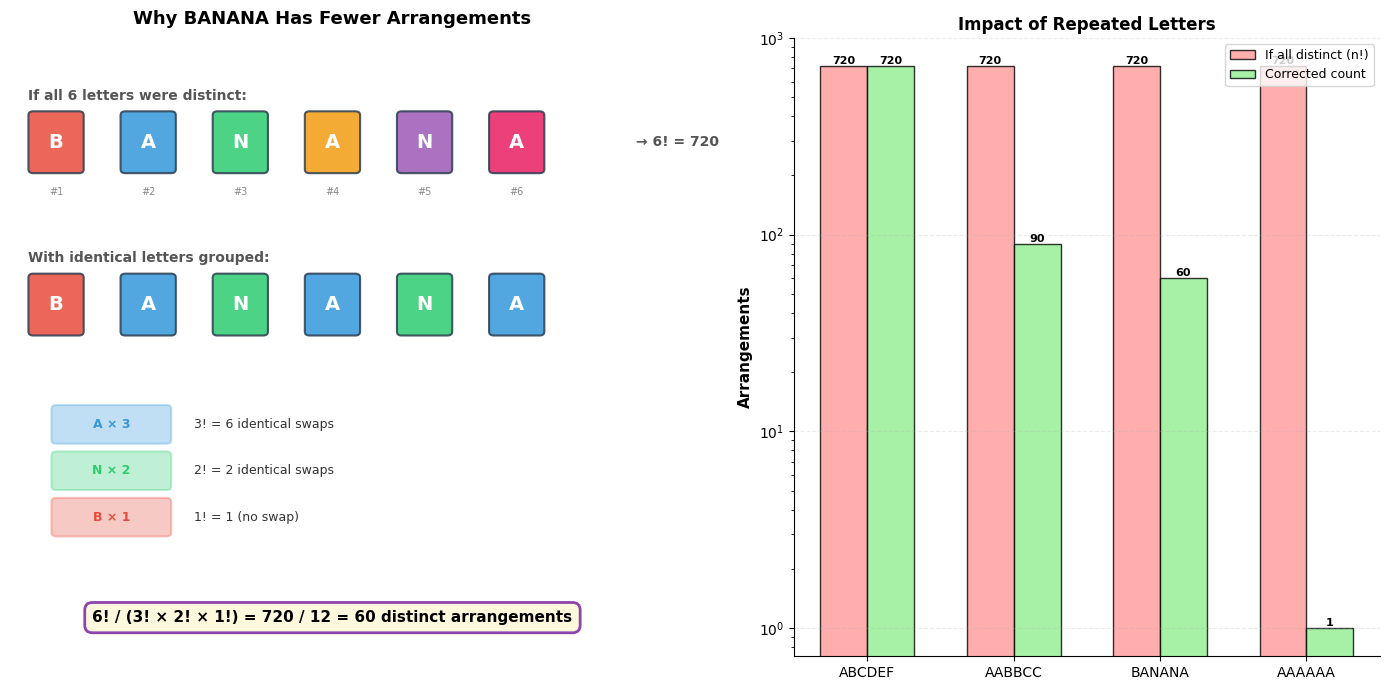

✓ Visual: Overcounting with repeated elements


In [119]:
# Visualize the overcounting concept for BANANA
fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1])

# Left: Show colored letters and overcounting visually
ax = fig.add_subplot(gs[0, 0])
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-1, 7)
ax.axis('off')
ax.set_title('Why BANANA Has Fewer Arrangements', fontsize=13, fontweight='bold', pad=10)

# Color each letter uniquely (as if distinct)
banana_letters = ['B', 'A', 'N', 'A', 'N', 'A']
letter_colors_distinct = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e91e63']
letter_colors_actual = ['#e74c3c', '#3498db', '#2ecc71', '#3498db', '#2ecc71', '#3498db']

# Row 1: "If all distinct" — colored uniquely
ax.text(-0.3, 6.2, 'If all 6 letters were distinct:', fontsize=10, fontweight='bold', color='#555')
for i, (letter, color) in enumerate(zip(banana_letters, letter_colors_distinct)):
    rect = patches.FancyBboxPatch((i - 0.25, 5.3), 0.5, 0.7,
                                   boxstyle='round,pad=0.05', facecolor=color, alpha=0.85,
                                   edgecolor='#2c3e50', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(i, 5.65, letter, ha='center', va='center', fontsize=14,
            fontweight='bold', color='white')
    ax.text(i, 5.0, f'#{i+1}', ha='center', va='center', fontsize=7, color='#888')
ax.text(6.3, 5.65, '→ 6! = 720', fontsize=10, fontweight='bold', va='center', color='#555')

# Row 2: "Actual coloring" — same letter = same color
ax.text(-0.3, 4.1, 'With identical letters grouped:', fontsize=10, fontweight='bold', color='#555')
for i, (letter, color) in enumerate(zip(banana_letters, letter_colors_actual)):
    rect = patches.FancyBboxPatch((i - 0.25, 3.2), 0.5, 0.7,
                                   boxstyle='round,pad=0.05', facecolor=color, alpha=0.85,
                                   edgecolor='#2c3e50', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(i, 3.55, letter, ha='center', va='center', fontsize=14,
            fontweight='bold', color='white')

# Show overcounting groups
group_info = [
    ('A × 3', '#3498db', '3! = 6 identical swaps'),
    ('N × 2', '#2ecc71', '2! = 2 identical swaps'),
    ('B × 1', '#e74c3c', '1! = 1 (no swap)'),
]
for j, (label, color, desc) in enumerate(group_info):
    y = 2.0 - j * 0.6
    rect = patches.FancyBboxPatch((0, y - 0.2), 1.2, 0.4,
                                   boxstyle='round,pad=0.05', facecolor=color, alpha=0.3,
                                   edgecolor=color, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(0.6, y, label, ha='center', va='center', fontsize=9, fontweight='bold', color=color)
    ax.text(1.5, y, desc, ha='left', va='center', fontsize=9, color='#333')

# Bottom result
ax.text(3, -0.5, '6! / (3! × 2! × 1!) = 720 / 12 = 60 distinct arrangements',
        ha='center', va='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8DC', edgecolor='#8e44ad', linewidth=2))

# Right: Bar chart comparison
ax = fig.add_subplot(gs[0, 1])

words_compare = ['ABCDEF', 'AABBCC', 'BANANA', 'AAAAAA']
if_distinct = [720, 720, 720, 720]
result_abcdef = math.factorial(6)
result_aabbcc = math.factorial(6) // (2 * 2 * 2)
result_banana = math.factorial(6) // (math.factorial(3) * math.factorial(2))
result_aaaaaa = math.factorial(6) // math.factorial(6)
with_repetition = [result_abcdef, result_aabbcc, result_banana, result_aaaaaa]

x = np.arange(len(words_compare))
width = 0.32
bars1 = ax.bar(x - width / 2, if_distinct, width, label='If all distinct (n!)',
               color='#ff9999', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width / 2, with_repetition, width, label='Corrected count',
               color='#90ee90', alpha=0.8, edgecolor='black')

ax.set_ylabel('Arrangements', fontsize=11, fontweight='bold')
ax.set_title('Impact of Repeated Letters', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(words_compare, fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.set_yscale('log')

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., h, f'{int(h)}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., h, f'{int(h)}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visual: Overcounting with repeated elements")

In [120]:
def permutations_with_repetition(items):
    """Count distinct permutations when items may repeat."""
    n = len(items)
    counts = Counter(items)
    numerator = math.factorial(n)
    denominator = 1
    for c in counts.values():
        denominator *= math.factorial(c)
    return numerator // denominator, n, counts

word = "BANANA"
result, n, counts = permutations_with_repetition(word)

print(f"Word: {word}")
print(f"Length: {n}")
print(f"Letter frequencies: {dict(counts)}")
print()

denom_part_list = []
for c in counts.values():
    denom_part_list.append(f"{c}!")
denom_parts = " × ".join(denom_part_list)

denom_value_list = []
for c in counts.values():
    denom_value_list.append(str(math.factorial(c)))
denom_values = " × ".join(denom_value_list)

denom = 1
for c in counts.values():
    denom *= math.factorial(c)

print(f"Formula: {n}! / ({denom_parts})")
print(f"       = {math.factorial(n)} / ({denom_values})")
print(f"       = {math.factorial(n)} / {denom}")
print(f"       = {result}")

Word: BANANA
Length: 6
Letter frequencies: {'B': 1, 'A': 3, 'N': 2}

Formula: 6! / (1! × 3! × 2!)
       = 720 / (1 × 6 × 2)
       = 720 / 12
       = 60


In [121]:
# Verify by brute force: generate all permutations and count unique ones
all_perms = set(permutations(word))
print(f"Brute force unique permutations of '{word}': {len(all_perms)}")
print(f"Formula result: {result}")
print(f"Match: {'✓' if len(all_perms) == result else '✗'}")
print()
print(f"Total permutations (treating all as distinct): {math.factorial(n)}")
print(f"Overcount factor: {math.factorial(n) // result}")

Brute force unique permutations of 'BANANA': 60
Formula result: 60
Match: ✓

Total permutations (treating all as distinct): 720
Overcount factor: 12


### Example 7: Arrangements of MISSISSIPPI

- M: 1, I: 4, S: 4, P: 2 → total 11 letters

$$\frac{11!}{1! \times 4! \times 4! \times 2!} = \frac{39916800}{1 \times 24 \times 24 \times 2} = \frac{39916800}{1152} = 34650$$

In [122]:
word = "MISSISSIPPI"
result, n, counts = permutations_with_repetition(word)

print(f"Word: {word}")
print(f"Length: {n}")
print(f"Letter frequencies: {dict(counts)}")
print()

denom_part_list = []
for c in counts.values():
    denom_part_list.append(f"{c}!")
denom_parts = " × ".join(denom_part_list)

denom = 1
for c in counts.values():
    denom *= math.factorial(c)

print(f"Formula: {n}! / ({denom_parts})")
print(f"       = {math.factorial(n):,} / {denom:,}")
print(f"       = {result:,}")

Word: MISSISSIPPI
Length: 11
Letter frequencies: {'M': 1, 'I': 4, 'S': 4, 'P': 2}

Formula: 11! / (1! × 4! × 4! × 2!)
       = 39,916,800 / 1,152
       = 34,650


### Example 8: Comparing Distinct vs Repeated

Let's see how repetition affects the count across a few words:

In [123]:
words = ["ABCDEF", "AABBCC", "AAAAAA", "ABCABC", "PEPPER"]

print(f"{'Word':<12} {'Length':>6} {'If all distinct':>16} {'With repetition':>16} {'Overcount':>10}")
print("-" * 64)

for word in words:
    result, n, counts = permutations_with_repetition(word)
    all_distinct = math.factorial(n)
    overcount = all_distinct // result
    print(f"{word:<12} {n:>6} {all_distinct:>16,} {result:>16,} {overcount:>10,}")

Word         Length  If all distinct  With repetition  Overcount
----------------------------------------------------------------
ABCDEF            6              720              720          1
AABBCC            6              720               90          8
AAAAAA            6              720                1        720
ABCABC            6              720               90          8
PEPPER            6              720               60         12


Notice:
- **ABCDEF** (all distinct): overcount = 1, no correction needed
- **AAAAAA** (all same): only 1 distinct arrangement regardless of length
- More repetition → larger overcount → fewer distinct arrangements

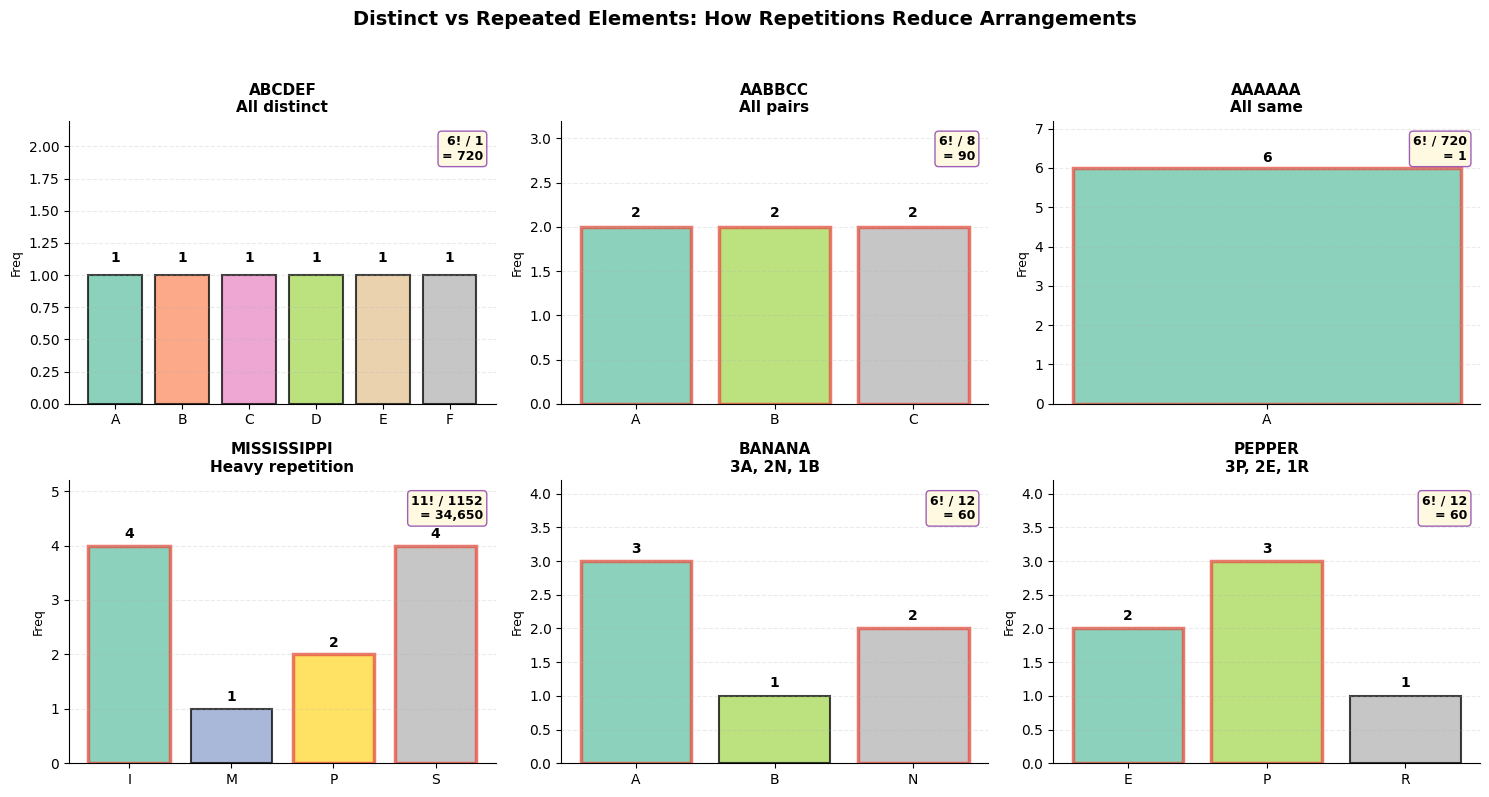

✓ Visual: Word comparison with repetitions


In [124]:
# Detailed comparison of words with different repetition patterns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distinct vs Repeated Elements: How Repetitions Reduce Arrangements',
             fontsize=14, fontweight='bold', y=0.99)

word_data = [
    ("ABCDEF", "All distinct"),
    ("AABBCC", "All pairs"),
    ("AAAAAA", "All same"),
    ("MISSISSIPPI", "Heavy repetition"),
    ("BANANA", "3A, 2N, 1B"),
    ("PEPPER", "3P, 2E, 1R"),
]

for idx, (word, desc) in enumerate(word_data):
    ax = axes[idx // 3, idx % 3]

    counts = Counter(word)
    letters = sorted(counts.keys())
    frequencies = [counts[l] for l in letters]

    n = len(word)
    numerator = math.factorial(n)
    denominator = 1
    for freq in frequencies:
        denominator *= math.factorial(freq)
    arrangements = numerator // denominator

    colors_freq = plt.cm.Set2(np.linspace(0, 1, len(letters)))
    bars = ax.bar(letters, frequencies, color=colors_freq, alpha=0.75, edgecolor='black', linewidth=1.5)

    for bar, freq in zip(bars, frequencies):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., h + 0.08, str(freq),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(f'{word}\n{desc}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Freq', fontsize=9)
    ax.set_ylim(0, max(frequencies) + 1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.25, linestyle='--')

    # Highlight repetitions in red border
    for bar, freq in zip(bars, frequencies):
        if freq > 1:
            bar.set_edgecolor('#e74c3c')
            bar.set_linewidth(2.5)

    # Result in top-right corner
    ax.text(0.97, 0.95, f'{n}! / {denominator}\n= {arrangements:,}',
            transform=ax.transAxes, fontsize=9, fontweight='bold',
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF8DC',
                      edgecolor='#8e44ad', alpha=0.85))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("✓ Visual: Word comparison with repetitions")

---
## 5. Bucketing Distinct Objects into Fixed-Size Groups

### The Dual Interpretation

The multinomial coefficient $\frac{n!}{n_1! \cdot n_2! \cdots n_k!}$ appears in two seemingly different problems that are **structurally identical**:

| Problem | What are the "items"? | What are the "slots"? |
|---------|----------------------|----------------------|
| **Permutations with repeats** | Positions in the sequence | Indistinguishable copies of each type |
| **Bucketing into fixed-size groups** | Distinct objects to assign | Groups (containers) of specified sizes |

**Why they're the same**: Assigning 13 distinct servers to groups of sizes (6, 4, 3) is like permuting the string `AAAAAABBBBCCC` — each unique permutation tells you which group each server goes to.

### Example: Assigning Servers to Datacenters

A company has **13 distinct servers** to assign to 3 datacenters with **6, 4, and 3** racks respectively.

**Step-by-step (product of combinations)**:

1. Choose 6 of 13 servers for Datacenter A: $\binom{13}{6}$ ways
2. Choose 4 of the remaining 7 for Datacenter B: $\binom{7}{4}$ ways
3. The last 3 go to Datacenter C: $\binom{3}{3} = 1$ way

$$\binom{13}{6} \times \binom{7}{4} \times \binom{3}{3} = \frac{13!}{6! \cdot 7!} \times \frac{7!}{4! \cdot 3!} \times 1 = \frac{13!}{6! \cdot 4! \cdot 3!}$$

The intermediate factorials cancel, leaving the **multinomial coefficient** — the same formula as permutations with repeated elements, just viewed from the other direction.

### Formula: Bucketing into Fixed-Size Groups

$$\binom{n}{n_1, n_2, \ldots, n_k} = \frac{n!}{n_1! \cdot n_2! \cdots n_k!}$$

where $n_1 + n_2 + \cdots + n_k = n$.

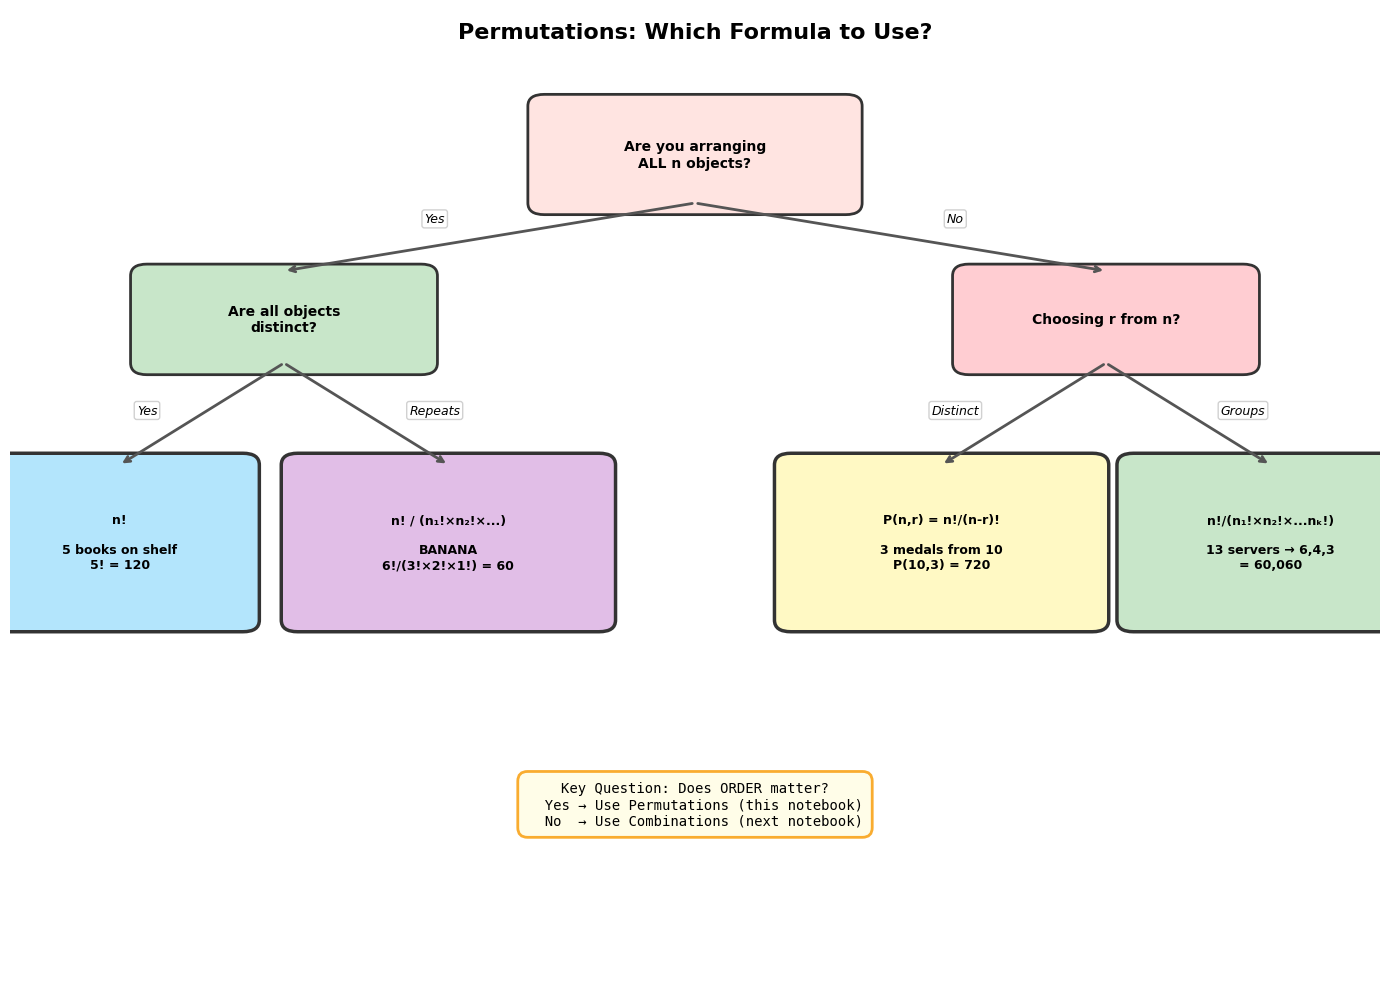

✓ Visual: Decision tree for permutation formulas


In [125]:
# Decision tree for choosing the right permutation formula
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

ax.text(5, 9.7, 'Permutations: Which Formula to Use?', fontsize=16, fontweight='bold', ha='center')

# ── Box definitions ──
box_defs = [
    # (x, y, text, color, width, height, is_formula)
    (5, 8.5, 'Are you arranging\nALL n objects?', '#FFE4E1', 2.2, 1.0, False),
    # YES branch
    (2, 6.8, 'Are all objects\ndistinct?', '#C8E6C9', 2.0, 0.9, False),
    # NO branch
    (8, 6.8, 'Choosing r from n?', '#FFCDD2', 2.0, 0.9, False),
    # Leaf: n!
    (0.8, 4.5, 'n!\n\n5 books on shelf\n5! = 120', '#B3E5FC', 1.8, 1.6, True),
    # Leaf: repetition
    (3.2, 4.5, 'n! / (n₁!×n₂!×...)\n\nBANANA\n6!/(3!×2!×1!) = 60', '#E1BEE7', 2.2, 1.6, True),
    # Leaf: P(n,r)
    (6.8, 4.5, 'P(n,r) = n!/(n-r)!\n\n3 medals from 10\nP(10,3) = 720', '#FFF9C4', 2.2, 1.6, True),
    # Leaf: Bucketing
    (9.2, 4.5, 'n!/(n₁!×n₂!×...nₖ!)\n\n13 servers → 6,4,3\n= 60,060', '#C8E6C9', 2.0, 1.6, True),
]

for (bx, by, text, color, w, h, is_formula) in box_defs:
    rect = patches.FancyBboxPatch((bx - w / 2, by - h / 2), w, h,
                                   boxstyle='round,pad=0.12',
                                   facecolor=color, edgecolor='#333',
                                   linewidth=2.5 if is_formula else 2)
    ax.add_patch(rect)
    ax.text(bx, by, text, ha='center', va='center',
            fontsize=9 if is_formula else 10, fontweight='bold')

# ── Arrows ──
arrow_kw = dict(arrowstyle='->', lw=2, color='#555')

def draw_arrow(x1, y1, x2, y2, label='', label_offset=(0.25, 0)):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=arrow_kw)
    if label:
        mx, my = (x1 + x2) / 2 + label_offset[0], (y1 + y2) / 2 + label_offset[1]
        ax.text(mx, my, label, fontsize=9, style='italic', ha='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, edgecolor='#ccc'))

# Root → left/right
draw_arrow(5, 8.0, 2, 7.3, 'Yes', (-0.4, 0.15))
draw_arrow(5, 8.0, 8, 7.3, 'No', (0.4, 0.15))
# Left → leaves
draw_arrow(2, 6.35, 0.8, 5.3, 'Yes', (-0.4, 0))
draw_arrow(2, 6.35, 3.2, 5.3, 'Repeats', (0.5, 0))
# Right → leaves
draw_arrow(8, 6.35, 6.8, 5.3, 'Distinct', (-0.5, 0))
draw_arrow(8, 6.35, 9.2, 5.3, 'Groups', (0.4, 0))

# Bottom key-insight box
key_text = ("Key Question: Does ORDER matter?\n"
            "  Yes → Use Permutations (this notebook)\n"
            "  No  → Use Combinations (next notebook)")
ax.text(5, 1.8, key_text, fontsize=10, ha='center', va='center', family='monospace',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='#FFFDE7', edgecolor='#F9A825',
                  linewidth=2, alpha=0.95))

plt.tight_layout()
plt.show()

print("✓ Visual: Decision tree for permutation formulas")

In [126]:
# Bucketing 13 distinct servers into datacenters with 6, 4, 3 racks
n = 13
groups = [6, 4, 3]

# Method 1: Multinomial coefficient = n! / (n1! × n2! × ... × nk!)
numerator = math.factorial(n)
denominator = 1
for g in groups:
    denominator *= math.factorial(g)
multinomial = numerator // denominator

print(f"Servers: {n}, Datacenter sizes: {groups}")
print()
print(f"Multinomial: {n}! / ({' × '.join(str(g) + '!' for g in groups)})")
print(f"           = {numerator:,} / {denominator:,}")
print(f"           = {multinomial:,}")
print()

# Method 2: Step-by-step combinations (product rule)
remaining = n
step_by_step = 1
steps = []
for g in groups:
    c = math.factorial(remaining) // (math.factorial(g) * math.factorial(remaining - g))
    steps.append(f"C({remaining}, {g}) = {c}")
    step_by_step *= c
    remaining -= g

print(f"Step-by-step: {' × '.join(steps)}")
print(f"            = {step_by_step:,}")
print()
print(f"Match: {'✓' if multinomial == step_by_step else '✗'}")

Servers: 13, Datacenter sizes: [6, 4, 3]

Multinomial: 13! / (6! × 4! × 3!)
           = 6,227,020,800 / 103,680
           = 60,060

Step-by-step: C(13, 6) = 1716 × C(7, 4) = 35 × C(3, 3) = 1
            = 60,060

Match: ✓


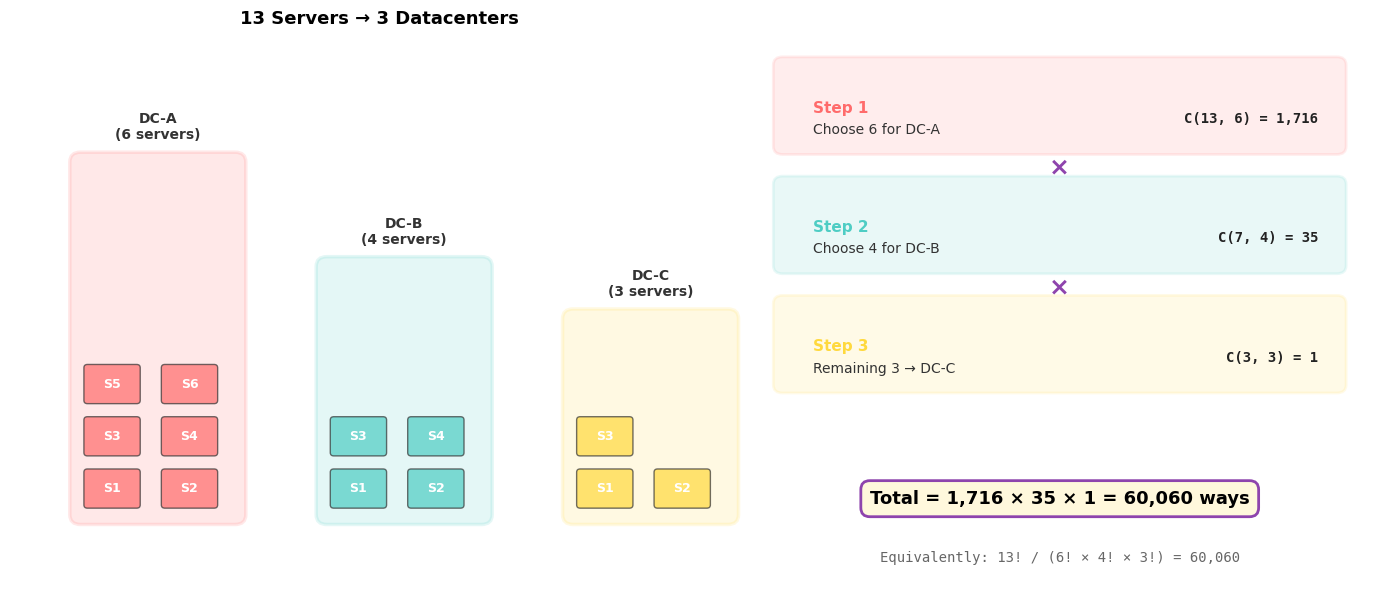

✓ Visual: Bucketing servers — 60,060 ways


In [127]:
# Visualize bucketing servers into datacenters
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.2, 1]})

# Left: Visual of servers flowing into datacenters
ax = axes[0]
ax.set_xlim(-0.5, 10)
ax.set_ylim(-0.8, 7.5)
ax.axis('off')
ax.set_title('13 Servers → 3 Datacenters', fontsize=13, fontweight='bold', pad=10)

dc_info = [
    ('DC-A', 6, '#FF6B6B', 0.5),
    ('DC-B', 4, '#4ECDC4', 4),
    ('DC-C', 3, '#FFD93D', 7.5),
]

for dc_name, size, color, x_start in dc_info:
    # Datacenter box
    box_w = 2.2
    box_h = 0.8 * size + 0.6
    rect = patches.FancyBboxPatch((x_start, 0.2), box_w, box_h,
                                   boxstyle='round,pad=0.15', facecolor=color, alpha=0.15,
                                   edgecolor=color, linewidth=2.5)
    ax.add_patch(rect)
    # DC label at top
    ax.text(x_start + box_w / 2, box_h + 0.5, f'{dc_name}\n({size} servers)',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333')

    # Server icons inside
    cols = 2
    for s in range(size):
        row = s // cols
        col = s % cols
        sx = x_start + 0.45 + col * 1.1
        sy = 0.6 + row * 0.8
        srv_rect = patches.FancyBboxPatch((sx - 0.35, sy - 0.25), 0.7, 0.5,
                                           boxstyle='round,pad=0.05', facecolor=color, alpha=0.7,
                                           edgecolor='#333', linewidth=1)
        ax.add_patch(srv_rect)
        ax.text(sx, sy, f'S{s + 1}', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')

# Right: Step-by-step calculation
ax = axes[1]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

steps_info = [
    ('Step 1', 'Choose 6 for DC-A', 'C(13, 6) = 1,716', '#FF6B6B'),
    ('Step 2', 'Choose 4 for DC-B', 'C(7, 4) = 35', '#4ECDC4'),
    ('Step 3', 'Remaining 3 → DC-C', 'C(3, 3) = 1', '#FFD93D'),
]

for i, (step, desc, calc, color) in enumerate(steps_info):
    y = 8.5 - i * 2.2
    rect = patches.FancyBboxPatch((0.3, y - 0.5), 9, 1.5,
                                   boxstyle='round,pad=0.15', facecolor=color, alpha=0.12,
                                   edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(0.8, y + 0.2, step, fontsize=11, fontweight='bold', va='center', color=color)
    ax.text(0.8, y - 0.2, desc, fontsize=10, va='center', color='#333')
    ax.text(9, y, calc, fontsize=10, fontweight='bold', ha='right', va='center',
            family='monospace', color='#222')
    if i < 2:
        ax.text(4.8, y - 0.9, '×', fontsize=18, ha='center', va='center',
                fontweight='bold', color='#8e44ad')

# Result
multinomial = math.factorial(13) // (math.factorial(6) * math.factorial(4) * math.factorial(3))
ax.text(4.8, 1.5, f'Total = 1,716 × 35 × 1 = {multinomial:,} ways',
        fontsize=13, fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8DC', edgecolor='#8e44ad', linewidth=2))

ax.text(4.8, 0.4, f'Equivalently: 13! / (6! × 4! × 3!) = {multinomial:,}',
        fontsize=10, ha='center', va='center', color='#666', family='monospace')

plt.tight_layout()
plt.show()

print(f"✓ Visual: Bucketing servers — {multinomial:,} ways")

---
## 6. Summary of Formulas

| Scenario | Formula | Example |
|----------|---------|--------|
| Arrange all $n$ distinct objects | $n!$ | 5 books on shelf: $5! = 120$ |
| Arrange $r$ of $n$ distinct objects | $P(n,r) = \frac{n!}{(n-r)!}$ | 3 medals from 10 runners: $P(10,3) = 720$ |
| Arrange all $n$ objects, some repeated | $\frac{n!}{n_1! \cdot n_2! \cdots n_k!}$ | BANANA: $\frac{6!}{3!2!1!} = 60$ |
| Bucket $n$ distinct objects into fixed-size groups | $\binom{n}{n_1, n_2, \ldots, n_k} = \frac{n!}{n_1! \cdot n_2! \cdots n_k!}$ | 13 servers into groups of 6, 4, 3: $60{,}060$ |

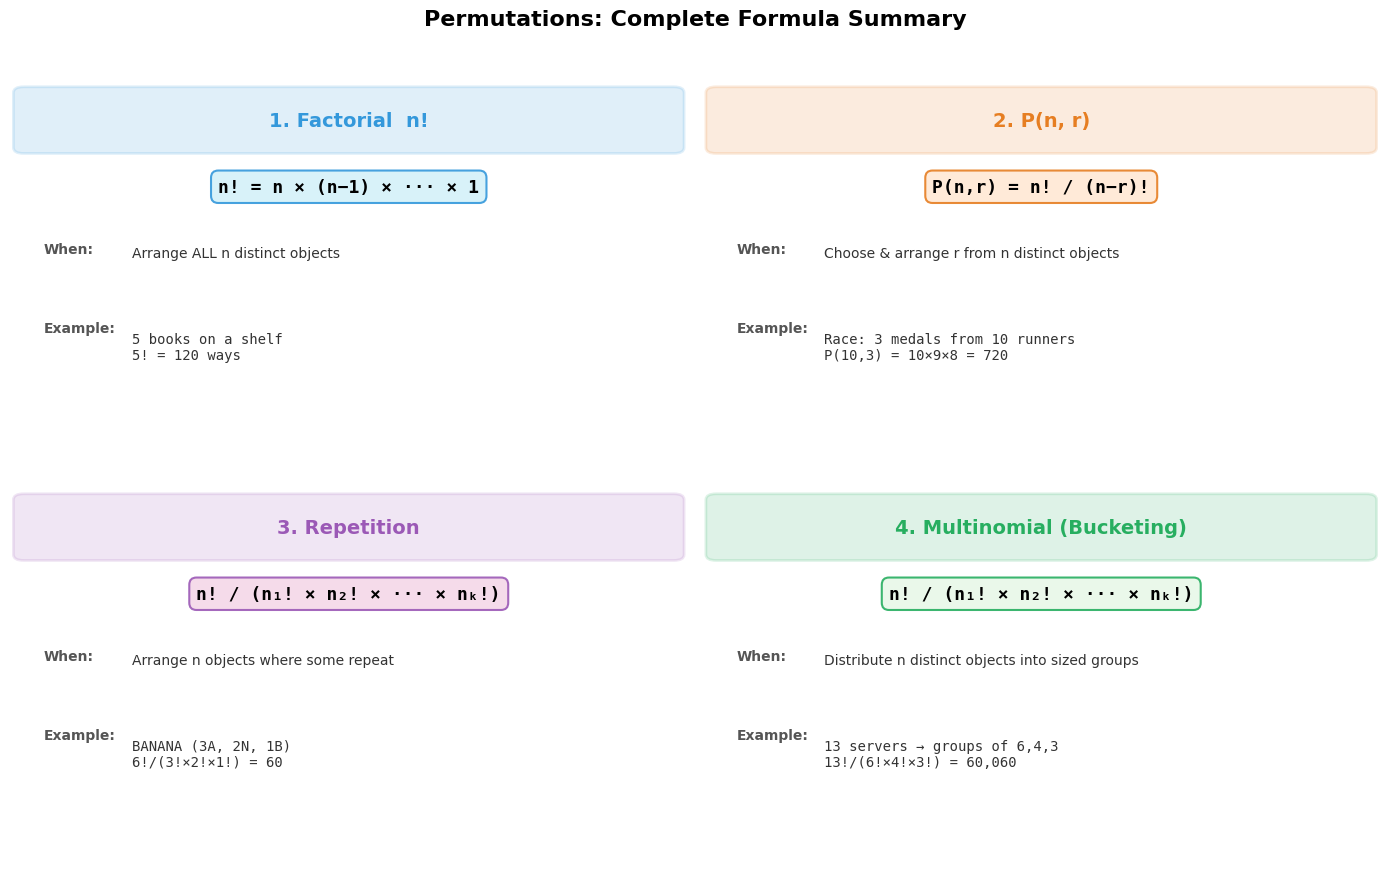

✓ Visual: Complete formula summary


In [128]:
# Create formula summary — clean reference card
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Permutations: Complete Formula Summary', fontsize=16, fontweight='bold', y=0.98)

formulas = [
    {
        'ax': axes[0, 0],
        'title': '1. Factorial  n!',
        'formula': 'n! = n × (n−1) × ··· × 1',
        'use': 'Arrange ALL n distinct objects',
        'example': '5 books on a shelf\n5! = 120 ways',
        'color': '#d4f1f9',
        'edge': '#3498db',
    },
    {
        'ax': axes[0, 1],
        'title': '2. P(n, r)',
        'formula': 'P(n,r) = n! / (n−r)!',
        'use': 'Choose & arrange r from n distinct objects',
        'example': 'Race: 3 medals from 10 runners\nP(10,3) = 10×9×8 = 720',
        'color': '#ffe8d4',
        'edge': '#e67e22',
    },
    {
        'ax': axes[1, 0],
        'title': '3. Repetition',
        'formula': 'n! / (n₁! × n₂! × ··· × nₖ!)',
        'use': 'Arrange n objects where some repeat',
        'example': 'BANANA (3A, 2N, 1B)\n6!/(3!×2!×1!) = 60',
        'color': '#f4d8e8',
        'edge': '#9b59b6',
    },
    {
        'ax': axes[1, 1],
        'title': '4. Multinomial (Bucketing)',
        'formula': 'n! / (n₁! × n₂! × ··· × nₖ!)',
        'use': 'Distribute n distinct objects into sized groups',
        'example': '13 servers → groups of 6,4,3\n13!/(6!×4!×3!) = 60,060',
        'color': '#e8f8e8',
        'edge': '#27ae60',
    },
]

for f in formulas:
    ax = f['ax']
    ax.axis('off')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)

    # Title banner
    rect = patches.FancyBboxPatch((0.2, 8.2), 9.6, 1.4,
                                   boxstyle='round,pad=0.15', facecolor=f['edge'],
                                   alpha=0.15, edgecolor=f['edge'], linewidth=2)
    ax.add_patch(rect)
    ax.text(5, 8.9, f['title'], ha='center', va='center',
            fontsize=14, fontweight='bold', color=f['edge'])

    # Formula
    ax.text(5, 7.2, f['formula'], ha='center', va='center',
            fontsize=13, fontweight='bold', family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=f['color'], edgecolor=f['edge'],
                      linewidth=1.5, alpha=0.9))

    # When to use
    ax.text(0.5, 5.5, 'When:', fontsize=10, fontweight='bold', color='#555')
    ax.text(1.8, 5.5, f['use'], fontsize=10, va='center', color='#333')

    # Example
    ax.text(0.5, 3.5, 'Example:', fontsize=10, fontweight='bold', color='#555')
    ax.text(1.8, 3.5, f['example'], fontsize=10, va='top', color='#333', family='monospace')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("✓ Visual: Complete formula summary")

---
## 7. Practice Problems

Try solving these on your own before running the solution cells!

### Problem 1: Committee Positions

A club has **12 members**. They need to elect a **President**, **Vice President**, and **Secretary**.

How many ways can these positions be filled? (No one can hold two positions.)

In [129]:
# SOLUTION
# Order matters (President ≠ Vice President), so this is P(12, 3)
n, r = 12, 3
result = P(n, r)

print(f"P({n}, {r}) = {n} × {n-1} × {n-2} = {result}")

P(12, 3) = 12 × 11 × 10 = 1320


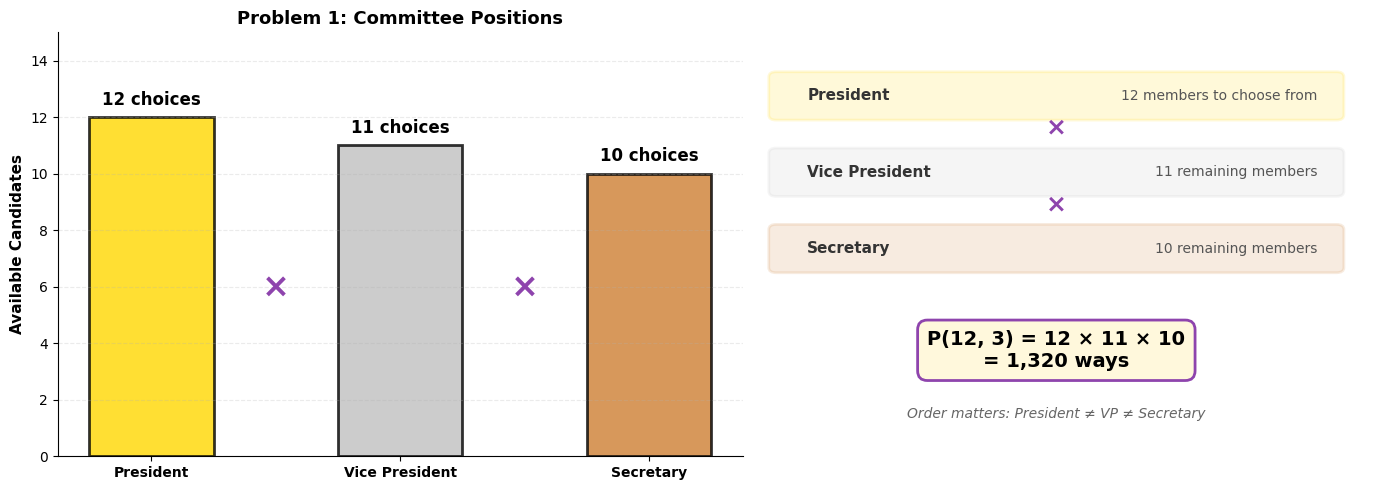

✓ Visual: Problem 1 — Committee = P(12,3) = 1,320


In [130]:
# Visualize the committee positions problem
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.1, 1]})

# Left: Bar chart of choices at each position
ax = axes[0]
positions = ['President', 'Vice President', 'Secretary']
choices = [12, 11, 10]
colors_pos = ['#FFD700', '#C0C0C0', '#CD7F32']

x_pos = np.arange(len(positions))
bars = ax.bar(x_pos, choices, color=colors_pos, alpha=0.8, edgecolor='black', linewidth=2, width=0.5)

for i, (pos, choice) in enumerate(zip(positions, choices)):
    ax.text(i, choice + 0.3, f'{choice} choices', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

for i in range(len(positions) - 1):
    ax.text(i + 0.5, 6, '×', ha='center', va='center', fontsize=24,
            fontweight='bold', color='#8e44ad')

ax.set_ylim(0, 15)
ax.set_ylabel('Available Candidates', fontsize=11, fontweight='bold')
ax.set_title('Problem 1: Committee Positions', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(positions, fontsize=10, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle='--')

# Right: Step-by-step with result
ax = axes[1]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

committee_result = P(12, 3)

steps_data = [
    ('President', '12 members to choose from', '#FFD700'),
    ('Vice President', '11 remaining members', '#C0C0C0'),
    ('Secretary', '10 remaining members', '#CD7F32'),
]
for i, (role, desc, color) in enumerate(steps_data):
    y = 8.5 - i * 1.8
    rect = patches.FancyBboxPatch((0.3, y - 0.45), 9, 0.9,
                                   boxstyle='round,pad=0.12', facecolor=color, alpha=0.15,
                                   edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(0.8, y, role, fontsize=11, fontweight='bold', va='center', color='#333')
    ax.text(9, y, desc, fontsize=10, ha='right', va='center', color='#555')
    if i < 2:
        ax.text(4.8, y - 0.75, '×', fontsize=18, ha='center', va='center',
                fontweight='bold', color='#8e44ad')

ax.text(4.8, 2.5, f'P(12, 3) = 12 × 11 × 10\n= {committee_result:,} ways',
        fontsize=14, fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8DC',
                  edgecolor='#8e44ad', linewidth=2))

ax.text(4.8, 1.0, 'Order matters: President ≠ VP ≠ Secretary',
        fontsize=10, ha='center', va='center', style='italic', color='#666')

plt.tight_layout()
plt.show()

print(f"✓ Visual: Problem 1 — Committee = P(12,3) = {committee_result:,}")

### Problem 2: Distinct Arrangements of MATHEMATICS

How many distinct arrangements of the letters in **MATHEMATICS** are there?

Hint: First count the frequency of each letter.

In [131]:
# SOLUTION
word = "MATHEMATICS"
result, n, counts = permutations_with_repetition(word)

print(f"Word: {word}")
print(f"Length: {n}")
print(f"Frequencies: {dict(counts)}")
print()

# M=2, A=2, T=2, H=1, E=1, I=1, C=1, S=1
denom_part_list = []
for c in counts.values():
    denom_part_list.append(f"{c}!")
denom_parts = " × ".join(denom_part_list)

print(f"Formula: {n}! / ({denom_parts}) = {result:,}")

Word: MATHEMATICS
Length: 11
Frequencies: {'M': 2, 'A': 2, 'T': 2, 'H': 1, 'E': 1, 'I': 1, 'C': 1, 'S': 1}

Formula: 11! / (2! × 2! × 2! × 1! × 1! × 1! × 1! × 1!) = 4,989,600


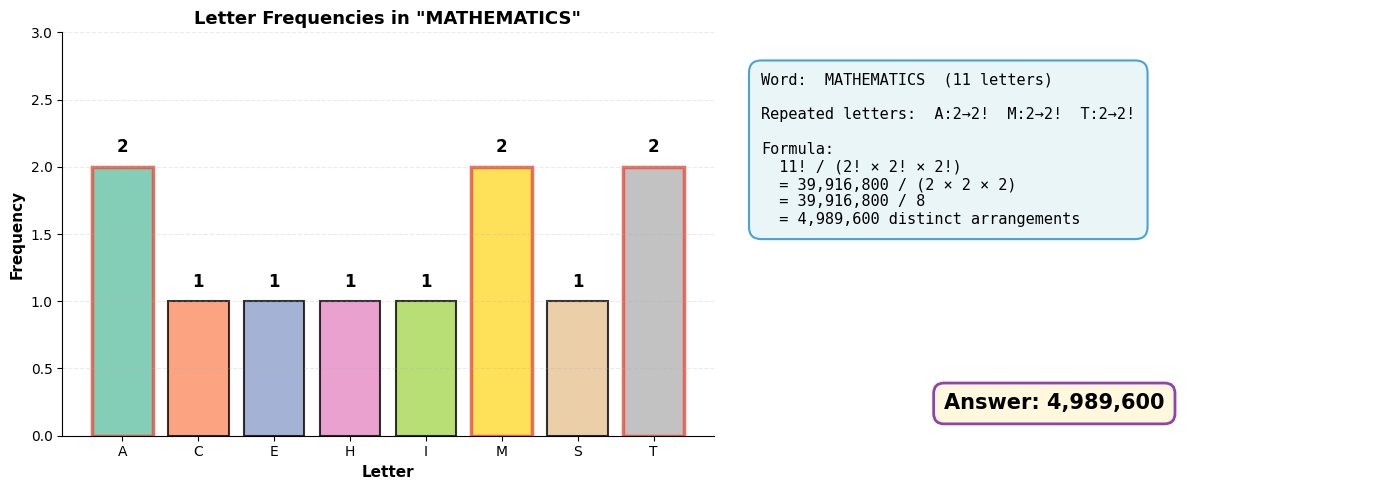

✓ Visual: Problem 2 — MATHEMATICS = 4,989,600


In [132]:
# Visualize MATHEMATICS problem
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1]})

word = "MATHEMATICS"
counts = Counter(word)

# Compute result directly
n_letters = len(word)
numerator = math.factorial(n_letters)
denominator = 1
for freq in counts.values():
    denominator *= math.factorial(freq)
math_answer = numerator // denominator

# Left: Styled letter-frequency bar chart
ax = axes[0]
letters = sorted(counts.keys())
frequencies = [counts[l] for l in letters]

colors_letters = plt.cm.Set2(np.linspace(0, 1, len(letters)))
bars = ax.bar(letters, frequencies, color=colors_letters, alpha=0.8, edgecolor='black', linewidth=1.5)

for bar, freq in zip(bars, frequencies):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., h + 0.08, str(freq),
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_xlabel('Letter', fontsize=11, fontweight='bold')
ax.set_title(f'Letter Frequencies in "{word}"', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(frequencies) + 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle='--')

# Highlight repeated letters
for bar, freq in zip(bars, frequencies):
    if freq > 1:
        bar.set_edgecolor('#e74c3c')
        bar.set_linewidth(2.5)

# Right: Calculation breakdown
ax = axes[1]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# Build denominator parts dynamically
denom_parts = []
denom_vals = []
for l in sorted(counts.keys()):
    f = counts[l]
    if f > 1:
        denom_parts.append(f'{l}:{f}→{f}!')
        denom_vals.append(f'{math.factorial(f)}')

denom_part_str = '  '.join(denom_parts)
denom_value_str = ' × '.join(denom_vals)

calc_lines = [
    f'Word:  {word}  ({n_letters} letters)',
    '',
    f'Repeated letters:  {denom_part_str}',
    '',
    f'Formula:',
    f'  {n_letters}! / ({" × ".join(f"{counts[l]}!" for l in sorted(counts) if counts[l] > 1)})',
    f'  = {numerator:,} / ({denom_value_str})',
    f'  = {numerator:,} / {denominator}',
    f'  = {math_answer:,} distinct arrangements',
]

ax.text(0.5, 9, '\n'.join(calc_lines), fontsize=11, va='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#e8f4f8', edgecolor='#3498db',
                  linewidth=1.5, alpha=0.9))

# Answer highlight
ax.text(5, 0.8, f'Answer: {math_answer:,}', fontsize=15, fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8DC', edgecolor='#8e44ad', linewidth=2))

plt.tight_layout()
plt.show()

print(f"✓ Visual: Problem 2 — MATHEMATICS = {math_answer:,}")

### Problem 3: Digit Arrangements

How many distinct **7-digit numbers** can be formed using the digits **1, 1, 2, 2, 2, 3, 3**?

In [133]:
# SOLUTION
digits = [1, 1, 2, 2, 2, 3, 3]
result, n, counts = permutations_with_repetition(digits)

print(f"Digits: {digits}")
print(f"Frequencies: {dict(counts)}")
print(f"Distinct arrangements: {n}! / (2! × 3! × 2!) = {result}")

Digits: [1, 1, 2, 2, 2, 3, 3]
Frequencies: {1: 2, 2: 3, 3: 2}
Distinct arrangements: 7! / (2! × 3! × 2!) = 210


### Problem 4: Ranking Students

In a class of **20 students**, how many ways can the **top 5** positions be assigned in an exam? (No ties.)

In [134]:
# SOLUTION
# Order matters (1st ≠ 2nd), choosing 5 from 20
n, r = 20, 5
result = P(n, r)

parts = []
for i in range(r):
    parts.append(str(n - i))
terms = " × ".join(parts)

print(f"P({n}, {r}) = {terms} = {result:,}")

P(20, 5) = 20 × 19 × 18 × 17 × 16 = 1,860,480


### Problem 5: Arranging Books on a Shelf

You have **3 identical math books**, **2 identical science books**, and **4 identical history books** (9 books total).

In how many **distinct** ways can they be arranged on a shelf?

In [135]:
# SOLUTION
# 9 books: M=3, S=2, H=4
n = 9
math_books = 3
science_books = 2
history_books = 4

result = math.factorial(n) // (math.factorial(math_books) * math.factorial(science_books) * math.factorial(history_books))

print(f"Total books: {n} (Math: {math_books}, Science: {science_books}, History: {history_books})")
print(f"Arrangements: {n}! / ({math_books}! × {science_books}! × {history_books}!)")
print(f"            = {math.factorial(n)} / ({math.factorial(math_books)} × {math.factorial(science_books)} × {math.factorial(history_books)})")
print(f"            = {result:,}")

Total books: 9 (Math: 3, Science: 2, History: 4)
Arrangements: 9! / (3! × 2! × 4!)
            = 362880 / (6 × 2 × 24)
            = 1,260


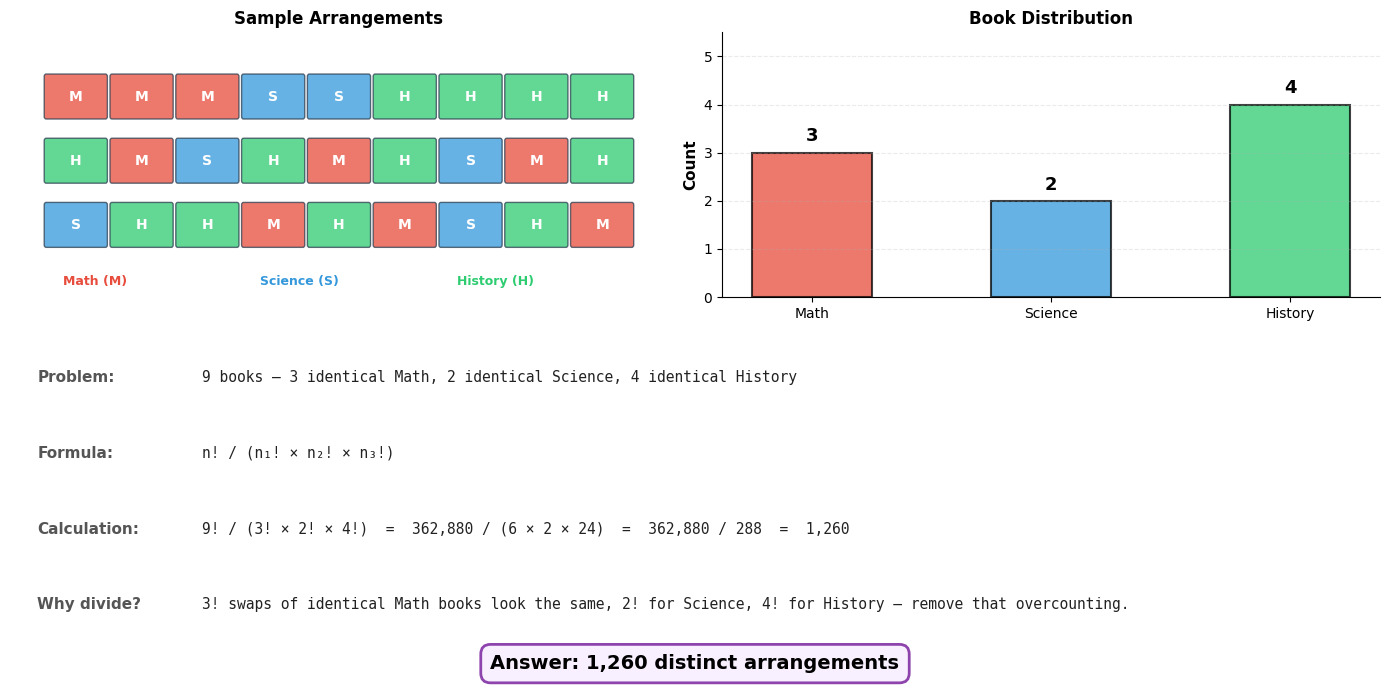

✓ Visual: Problem 5 — Books on Shelf = 1,260


In [136]:
# Visualize books on shelf problem
fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.3])

math_books_count, science_books_count, history_books_count = 3, 2, 4
total_books = 9

# Top-left: Example arrangements with colored blocks
ax = fig.add_subplot(gs[0, 0])
ax.set_xlim(-0.5, 9.5)
ax.set_ylim(-0.3, 3)
ax.axis('off')
ax.set_title('Sample Arrangements', fontsize=12, fontweight='bold')

arrangements_shown = [
    ['M', 'M', 'M', 'S', 'S', 'H', 'H', 'H', 'H'],
    ['H', 'M', 'S', 'H', 'M', 'H', 'S', 'M', 'H'],
    ['S', 'H', 'H', 'M', 'H', 'M', 'S', 'H', 'M'],
]
colors_books = {'M': '#e74c3c', 'S': '#3498db', 'H': '#2ecc71'}
type_names = {'M': 'Math', 'S': 'Science', 'H': 'History'}

for row_idx, arr in enumerate(arrangements_shown):
    y = 2.2 - row_idx * 0.8
    for col_idx, book in enumerate(arr):
        rect = patches.FancyBboxPatch((col_idx + 0.05, y - 0.25), 0.9, 0.5,
                                       boxstyle='round,pad=0.03',
                                       facecolor=colors_books[book], alpha=0.75,
                                       edgecolor='#2c3e50', linewidth=1)
        ax.add_patch(rect)
        ax.text(col_idx + 0.5, y, book, ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

# Legend
for i, (code, name) in enumerate(type_names.items()):
    ax.text(0.3 + i * 3, -0.1, f'{name} ({code})', fontsize=9, fontweight='bold',
            color=colors_books[code], va='center')

# Top-right: Book distribution bar chart
ax = fig.add_subplot(gs[0, 1])
book_types = ['Math', 'Science', 'History']
book_counts = [math_books_count, science_books_count, history_books_count]
colors_type = ['#e74c3c', '#3498db', '#2ecc71']

bars = ax.bar(book_types, book_counts, color=colors_type, alpha=0.75,
              edgecolor='black', linewidth=1.5, width=0.5)
for bar, count in zip(bars, book_counts):
    ax.text(bar.get_x() + bar.get_width() / 2., count + 0.15, str(count),
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Count', fontsize=11, fontweight='bold')
ax.set_title('Book Distribution', fontsize=12, fontweight='bold')
ax.set_ylim(0, 5.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle='--')

# Bottom (spanning): Calculation
ax = fig.add_subplot(gs[1, :])
ax.axis('off')

numerator = math.factorial(total_books)
denominator = (math.factorial(math_books_count) *
               math.factorial(science_books_count) *
               math.factorial(history_books_count))
answer = numerator // denominator

calc_lines = [
    ('Problem:', f'{total_books} books — {math_books_count} identical Math, '
                 f'{science_books_count} identical Science, {history_books_count} identical History'),
    ('Formula:', 'n! / (n₁! × n₂! × n₃!)'),
    ('Calculation:',
     f'{total_books}! / ({math_books_count}! × {science_books_count}! × {history_books_count}!)  '
     f'=  {numerator:,} / ({math.factorial(math_books_count)} × '
     f'{math.factorial(science_books_count)} × {math.factorial(history_books_count)})  '
     f'=  {numerator:,} / {denominator}  =  {answer:,}'),
    ('Why divide?',
     f'{math_books_count}! swaps of identical Math books look the same, '
     f'{science_books_count}! for Science, {history_books_count}! for History — '
     f'remove that overcounting.'),
]

y_start = 0.9
for label, text in calc_lines:
    ax.text(0.02, y_start, label, fontsize=11, fontweight='bold', va='top',
            transform=ax.transAxes, color='#555')
    ax.text(0.14, y_start, text, fontsize=10.5, va='top', transform=ax.transAxes,
            color='#222', family='monospace')
    y_start -= 0.22

# Highlight answer
ax.text(0.5, 0.02, f'Answer: {answer:,} distinct arrangements',
        fontsize=14, fontweight='bold', ha='center', va='bottom', transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f9f0ff', edgecolor='#8e44ad', linewidth=2))

plt.tight_layout()
plt.show()

print(f"✓ Visual: Problem 5 — Books on Shelf = {answer:,}")

### Problem 6: Strings from Letters

How many **4-letter strings** can be formed from the letters **A, B, C, D, E** if:

**Part A**: No repetition allowed?

**Part B**: Repetition is allowed?

In [137]:
# SOLUTION
n = 5  # letters A-E
r = 4  # string length

# Part A: No repetition → P(n, r)
part_a = P(n, r)
print(f"Part A (no repetition):  P({n}, {r}) = {n} × {n-1} × {n-2} × {n-3} = {part_a}")

# Part B: Repetition allowed → n^r (product rule, n choices at each of r positions)
part_b = n ** r
print(f"Part B (with repetition): {n}⁴ = {part_b}")
print()
print(f"Repetition adds {part_b - part_a} more possibilities.")

Part A (no repetition):  P(5, 4) = 5 × 4 × 3 × 2 = 120
Part B (with repetition): 5⁴ = 625

Repetition adds 505 more possibilities.


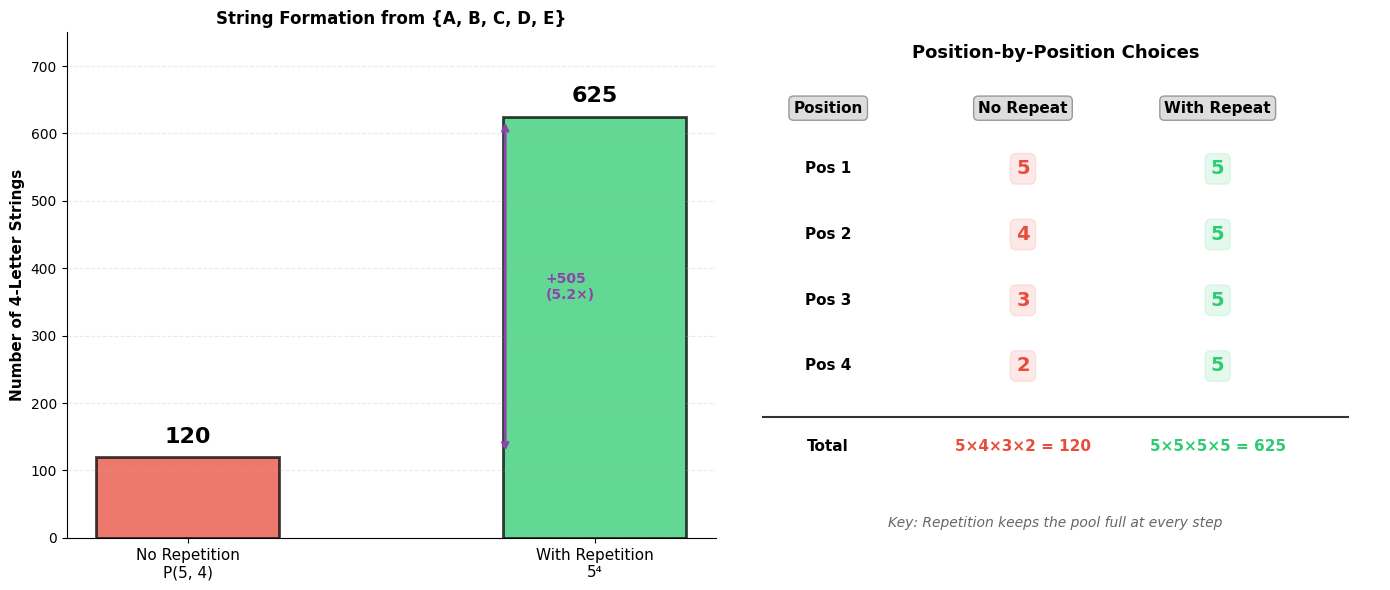

✓ Visual: Strings — no repeat 120, with repeat 625


In [138]:
# Visualize Problem 6: Strings with and without repetition
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1]})

n, r = 5, 4
part_a_result = P(5, 4)  # 120
part_b_result = 5 ** 4    # 625

# Left: Side-by-side comparison with step breakdown
ax = axes[0]

scenarios = ['No Repetition\nP(5, 4)', 'With Repetition\n5⁴']
results = [part_a_result, part_b_result]
colors_scenario = ['#e74c3c', '#2ecc71']

x = np.arange(len(scenarios))
bars = ax.bar(x, results, color=colors_scenario, alpha=0.75, edgecolor='black', linewidth=2, width=0.45)

for bar, val in zip(bars, results):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., h + 15, str(val),
            ha='center', va='bottom', fontsize=16, fontweight='bold')

ax.set_ylabel('Number of 4-Letter Strings', fontsize=11, fontweight='bold')
ax.set_title('String Formation from {A, B, C, D, E}', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=11)
ax.set_ylim(0, 750)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle='--')

# Difference annotation — vertical bracket between bars
diff = part_b_result - part_a_result
ratio = part_b_result / part_a_result
ax.annotate('', xy=(0.78, part_b_result - 5), xytext=(0.78, part_a_result + 5),
            arrowprops=dict(arrowstyle='<->', color='#8e44ad', lw=2))
ax.text(0.88, (part_a_result + part_b_result) / 2, f'+{diff}\n({ratio:.1f}×)',
        ha='left', va='center', fontsize=10, fontweight='bold', color='#8e44ad')

# Right: Position-by-position comparison
ax = axes[1]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

ax.text(5, 9.5, 'Position-by-Position Choices', fontsize=13, fontweight='bold', ha='center')

headers = ['Position', 'No Repeat', 'With Repeat']
col_x = [1.5, 4.5, 7.5]
for i, h in enumerate(headers):
    ax.text(col_x[i], 8.5, h, ha='center', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#ddd', edgecolor='#999'))

no_rep = [5, 4, 3, 2]
with_rep = [5, 5, 5, 5]

for j in range(4):
    y = 7.3 - j * 1.3
    ax.text(col_x[0], y, f'Pos {j+1}', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(col_x[1], y, str(no_rep[j]), ha='center', va='center', fontsize=14, fontweight='bold',
            color='#e74c3c',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#e74c3c', alpha=0.12, edgecolor='#e74c3c'))
    ax.text(col_x[2], y, str(with_rep[j]), ha='center', va='center', fontsize=14, fontweight='bold',
            color='#2ecc71',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#2ecc71', alpha=0.12, edgecolor='#2ecc71'))

# Totals
y_total = 1.8
ax.plot([0.5, 9.5], [y_total + 0.6, y_total + 0.6], color='#333', linewidth=1.5)
ax.text(col_x[0], y_total, 'Total', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(col_x[1], y_total, f'5×4×3×2 = {part_a_result}', ha='center', va='center',
        fontsize=11, fontweight='bold', color='#e74c3c')
ax.text(col_x[2], y_total, f'5×5×5×5 = {part_b_result}', ha='center', va='center',
        fontsize=11, fontweight='bold', color='#2ecc71')

# Key insight
ax.text(5, 0.3, 'Key: Repetition keeps the pool full at every step',
        ha='center', va='center', fontsize=10, style='italic', color='#666')

plt.tight_layout()
plt.show()

print(f"✓ Visual: Strings — no repeat {part_a_result}, with repeat {part_b_result}")

---
## 8. What's Next?

Permutations count **ordered** arrangements. But many problems ask:

> *How many ways can we **choose** $r$ items from $n$, where order does **not** matter?*

For example, choosing 3 people from 10 for a committee (no positions) — the group {Alice, Bob, Carol} is the same as {Carol, Alice, Bob}.

This leads to **combinations**, which we derive by correcting permutations for the overcount due to ordering:

$$C(n, r) = \frac{P(n, r)}{r!} = \frac{n!}{r!(n-r)!}$$

→ *Next notebook: Combinations*